# 🎾 Detección de Fatiga en Jugadores de Pádel
## Forecasting

---

### Pregunta Central
> **¿El rendimiento físico de un jugador sigue un patrón predecible durante el partido, y se puede anticipar cuándo empieza a decaer?**

**Hipótesis**: La desplazamiento total por punto por punto de un jugador decae progresivamente a lo largo del partido como consecuencia de la fatiga acumulada. Este decaimiento puede modelarse y anticiparse con técnicas de forecasting.

**Temas del módulo de Forecasting aplicados**:
1. Promedios Móviles y Suavizamiento Exponencial (SMA, EMA) — Grupo 12
2. Evaluación de Modelos de Forecasting (MAE, RMSE, train/test) — Grupo 11
3. ARIMA
4. Prophet de Meta — Grupo 13

In [1]:
# ============================================================
# CELDA 0 — Instalación de dependencias (ejecutar UNA vez)
# ============================================================
import subprocess, sys

paquetes = [
    'prophet',
    'statsmodels',
    'scikit-learn',
    'scipy',
    'openpyxl',
]

print('Verificando e instalando dependencias...')
for pkg in paquetes:
    try:
        __import__(pkg.replace('-', '_').split('[')[0])
        print(f'  ✅ {pkg} ya instalado')
    except ImportError:
        print(f'  ⏳ Instalando {pkg}...')
        result = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            print(f'  ✅ {pkg} instalado correctamente')
        else:
            print(f'  ❌ Error instalando {pkg}: {result.stderr[:200]}')

print('\n✅ Verificación completada.')

Verificando e instalando dependencias...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


  ✅ prophet ya instalado
  ✅ statsmodels ya instalado
  ⏳ Instalando scikit-learn...
  ✅ scikit-learn instalado correctamente
  ✅ scipy ya instalado
  ✅ openpyxl ya instalado

✅ Verificación completada.


## 📦 SECCIÓN 1 — Importaciones

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Series temporales
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prophet (Meta)
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
    print('✅ Prophet disponible')
except ImportError:
    PROPHET_AVAILABLE = False
    print('⚠️  Prophet no instalado. Para instalarlo: pip install prophet')

print('✅ Librerías importadas correctamente')
from scipy import stats


✅ Prophet disponible
✅ Librerías importadas correctamente


## ⚙️ SECCIÓN 2 — Configuración y Carga de Datos

> **Solo necesitas cambiar `PARTIDO_NUM`** para seleccionar el partido a analizar.
> El resto de parámetros (umbral de velocidad, proporción train/test, orden ARIMA) se calculan automáticamente a partir de los datos.

In [3]:
# ============================================================
# CONFIGURACIÓN — solo editar esto
# ============================================================
PARTIDO_NUM = 1   # Número del partido a analizar
# ============================================================
print(f'Partido seleccionado: {PARTIDO_NUM}')

Partido seleccionado: 1


In [5]:
# ---- Cargar Base_Videos_Final_202601.csv --------------------
CSV_PATH = Path('Base_Videos_Final_202601.csv')
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f'\n❌ No se encontró el archivo {CSV_PATH.name}.\n'
        'Asegúrate de que esté en la misma carpeta que este notebook.'
    )

print('⏳ Cargando Base_Videos_Final_202601.csv...')
df_raw = pd.read_csv(CSV_PATH)
print(f'✅ CSV cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'   Partidos disponibles: {sorted(df_raw["partido"].unique())}')

⏳ Cargando Base_Videos_Final_202601.csv...
✅ CSV cargado: 434,198 filas × 30 columnas
   Partidos disponibles: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(14), np.int64(15), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(24), np.int64(25), np.int64(27), np.int64(28), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(38)]


In [6]:
# ---- Filtrar partido seleccionado ---------------------------
if PARTIDO_NUM not in df_raw['partido'].values:
    disponibles = sorted(df_raw['partido'].unique())
    raise ValueError(
        f'\n❌ El partido {PARTIDO_NUM} no existe en el CSV.\n'
        f'Partidos disponibles: {disponibles}'
    )

df = df_raw[df_raw['partido'] == PARTIDO_NUM].copy()
print(f'✅ Partido {PARTIDO_NUM}: {len(df):,} frames')
print(f'   Puntos encontrados: {sorted(df["punto"].unique())}')

# ---- Umbral de velocidad físico fijo ------------------------
# Un jugador de pádel no supera ~6 m/s en sprint.
# El percentil-99 dinámico producía umbrales de 100 m/s (ruido YOLO).
# Usamos 8 m/s como límite conservador pero razonable.
VEL_MAX_MS = 8.0
print(f'   Umbral de velocidad (fijo, físicamente justificado): {VEL_MAX_MS:.2f} m/s')

# ---- Limpiar datos ------------------------------------------
# 1. Excluir jugadores sin nombre real (Player_XXXX)
df = df[~df['player_name'].str.match(r'^Player_\d+$', na=False)]

# 2. Eliminar velocidades fuera del rango físicamente posible
df = df[df['player_speed_mps'] <= VEL_MAX_MS]  # ceros conservados: representan frames estáticos

# 3. Limpiar team: si está vacío asignar 'unknown'
df['team'] = df['team'].fillna('unknown').replace('', 'unknown')

# 4. Team canónico por jugador: usa la moda en TODO el partido, no por punto.
#    Evita que un jugador aparezca en dos equipos distintos por ruido de tracking.
_team_canonico = (
    df.groupby('player_name')['team']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
df['team'] = df['player_name'].map(_team_canonico)

print(f'\nDespués de limpieza: {len(df):,} frames')
print(f'Jugadores reales en partido {PARTIDO_NUM}:')
for nombre in sorted(df['player_name'].unique()):
    equipo = _team_canonico.get(nombre, '?')
    frames = len(df[df['player_name'] == nombre])
    print(f'   • {nombre}  (equipo: {equipo}, {frames} frames)')

✅ Partido 1: 6,596 frames
   Puntos encontrados: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
   Umbral de velocidad calculado (percentil 99): 100.45 m/s

Después de limpieza: 6,317 frames
Jugadores reales en partido 1:
   • SANTIAGO PEÑA BELTRAN  (equipo: bottom, 2212 frames)
   • Sahily Andrea Herrera Eljadue  (equipo: top, 2194 frames)
   • Ángel Santiago Toribio Godoy   (equipo: bottom, 1911 frames)


## 🔧 SECCIÓN 2B — Preprocesamiento: del Dato Crudo a la Serie Temporal

El archivo `Base_Videos_Final_202601.csv` contiene datos **frame a frame** generados por el sistema de tracking YOLO — cada fila es un instante de video (~60 fps), no una jugada.

| Nivel | Filas | Qué representa |
|---|---|---|
| **Crudo** (frame-level) | ~434 000 | Una medición cada ~17 ms — inutilizable directo para forecasting |
| **Agregado** (punto-level) | ~40–60 por partido | Una fila por jugador por punto — **esta es la serie temporal** |

### ¿Por qué agrupar por jugador + punto?

El objetivo es construir una **serie temporal de rendimiento físico**: eje X = número de punto jugado, eje Y = desplazamiento total del jugador en ese punto. Para eso necesitamos colapsar los cientos de frames de cada punto en un único valor representativo.

**Variables calculadas en la agregación:**
- `desplazamiento_total` — metros recorridos en el punto (variable principal del forecasting)
- `velocidad_promedio` — velocidad media incluyendo frames estáticos (contexto de actividad)
- `velocidad_mediana_activa` — mediana de frames con movimiento real (métrica robusta secundaria)
- `velocidad_max_filtrada` — pico de velocidad dentro del umbral físico
- `mean_acceleration` — aceleración media (m/s²): cambios de ritmo
- `n_frames` — frames del punto: duración relativa del rally

In [7]:
# ── PASO 1: Vista del dato crudo ─────────────────────────────────────────────
print(f'Dato crudo (frame-level) — Partido {PARTIDO_NUM}')
print(f'  Filas totales : {len(df):,}')
print(f'  Columnas      : {df.shape[1]}')
print(f'  Frames/segundo (aprox): {1 / df["duration"].median():.0f} fps')
print()
print('Muestra de 3 filas del dato crudo:')
_cols_muestra = ['frame_idx', 'player_name', 'team', 'punto',
                 'player_speed_mps', 'player_displacement', 'player_acceleration_mps2']
print(df[_cols_muestra].head(3).to_string(index=False))
print()
print('→ Cada fila es un instante de video. No tiene sentido modelar esto directo.')
print('→ Hay que colapsar los frames de cada punto en un solo valor por jugador.')

# ── PASO 2: Agregación por jugador + punto ───────────────────────────────────
print()
print('Agrupando por jugador + punto...')

serie_temporal = (
    df.groupby(['punto', 'player_name'])
    .agg(
        partido                = ('partido',                 'first'),
        team                   = ('team',                   'first'),
        desplazamiento_total   = ('player_displacement',     'sum'),    # VARIABLE PRINCIPAL
        velocidad_promedio     = ('player_speed_mps',        'mean'),   # media incluyendo ceros
        velocidad_max_filtrada = ('player_speed_mps',        'max'),
        velocidad_mediana_activa = ('player_speed_mps',
                                   lambda x: x[x > 0].median() if (x > 0).any() else 0.0),
        mean_acceleration      = ('player_acceleration_mps2','mean'),
        n_frames               = ('frame_idx',               'count')
    )
    .reset_index()
    .rename(columns={'punto': 'punto_num'})
    .sort_values(['player_name', 'punto_num'])
    .reset_index(drop=True)
)

print(f'✅ Agregación completada:')
print(f'   Filas originales  : {len(df):,}  (frame-level)')
print(f'   Filas agregadas   : {len(serie_temporal)}  (punto-level)')
print(f'   Factor de reducción: {len(df) / len(serie_temporal):.0f}x')
print()
print('Resultado — primeras filas de la serie temporal:')
_preview_cols = ['partido', 'punto_num', 'player_name', 'team',
                 'desplazamiento_total', 'velocidad_promedio',
                 'velocidad_mediana_activa', 'velocidad_max_filtrada', 'n_frames']
print(serie_temporal[_preview_cols].head(8).to_string(index=False))

# ── Variables globales usadas en el resto del notebook ───────────────────────
jugadores = sorted(serie_temporal['player_name'].unique())
equipos   = serie_temporal.drop_duplicates('player_name').set_index('player_name')['team'].to_dict()

_col_bottom = ['#1565C0', '#0288D1']
_col_top    = ['#C62828', '#EF6C00']
color_map = {}
for i, j in enumerate([p for p in jugadores if equipos.get(p) in ('bottom', 'BOTTOM')]):
    color_map[j] = _col_bottom[i % len(_col_bottom)]
for i, j in enumerate([p for p in jugadores if equipos.get(p) not in ('bottom', 'BOTTOM', 'unknown')]):
    color_map[j] = _col_top[i % len(_col_top)]
for j in jugadores:
    if j not in color_map:
        color_map[j] = 'gray'

print()
print(f'Jugadores en partido {PARTIDO_NUM}: {jugadores}')

✅ Serie temporal construida:
   Jugadores: 3
   Puntos   : 11
   Total obs: 33

    punto_num                    player_name    team  avg_speed  total_displacement   max_speed  n_frames
0           1          SANTIAGO PEÑA BELTRAN  bottom   0.313469            1.640488    1.697056       157
1           2          SANTIAGO PEÑA BELTRAN  bottom   3.974356           36.034162  100.126320       272
2           3          SANTIAGO PEÑA BELTRAN  bottom   0.136260            0.622254    1.697056       137
3           4          SANTIAGO PEÑA BELTRAN  bottom   0.853609            4.751758   67.882251       167
4           5          SANTIAGO PEÑA BELTRAN  bottom   0.219763            1.018234    1.697056       139
5           6          SANTIAGO PEÑA BELTRAN  bottom   0.175283            1.244508    3.394113       213
6           7          SANTIAGO PEÑA BELTRAN  bottom   0.235702            2.262742    1.697056       288
7           8          SANTIAGO PEÑA BELTRAN  bottom   0.315168         

In [8]:
# ---- Cargar Traza_Datos_Partidos (ganador por punto) --------
TRAZA_PATH = Path('Traza_Datos_Partidos_202601.xlsx')
ganador_por_punto = {}   # {punto_num: 'EQUIPO_1' | 'EQUIPO_2'}
traza_partido = None

if TRAZA_PATH.exists():
    df_c1 = pd.read_excel(TRAZA_PATH, sheet_name='CANCHA_1')
    df_c2 = pd.read_excel(TRAZA_PATH, sheet_name='CANCHA_2')
    traza_all = pd.concat([df_c1, df_c2], ignore_index=True)
    traza_partido = traza_all[traza_all['ID_PARTIDO'] == PARTIDO_NUM]
    if not traza_partido.empty:
        for _, row in traza_partido.iterrows():
            if row['PUNTO_EQUIPO_1'] > row['PUNTO_EQUIPO_2']:
                ganador_por_punto[int(row['ID_PUNTO'])] = 'EQUIPO_1'
            elif row['PUNTO_EQUIPO_2'] > row['PUNTO_EQUIPO_1']:
                ganador_por_punto[int(row['ID_PUNTO'])] = 'EQUIPO_2'
        print(f'✅ Traza cargada para Partido {PARTIDO_NUM}: {len(ganador_por_punto)} puntos con ganador')
        print(f'   Jugadores equipo 1: {traza_partido.iloc[0]["ID_JUGADOR_1_EQUIPO_1"]} / {traza_partido.iloc[0]["ID_JUGADOR_2_EQUIPO_1"]}')
        print(f'   Jugadores equipo 2: {traza_partido.iloc[0]["ID_JUGADOR_1_EQUIPO_2"]} / {traza_partido.iloc[0]["ID_JUGADOR_2_EQUIPO_2"]}')
        equipo1_pos = traza_partido.iloc[0]['EQUIPO_1_POSICION'].lower()
        print(f'   Equipo 1 posición : {equipo1_pos}  → en CSV team={equipo1_pos}')
    else:
        print(f'⚠️  Partido {PARTIDO_NUM} no encontrado en la Traza. Se continúa sin info de ganador.')
else:
    print('⚠️  Traza_Datos_Partidos_202601.xlsx no encontrado. Se continúa sin info de ganador.')

# ---- Cargar Data_Jugadores (datos físicos) -------------------
JUG_PATH = Path('Data_Jugadores_202601.xlsx')
df_jugadores_info = None

if JUG_PATH.exists():
    df_jugadores_info = pd.read_excel(JUG_PATH, sheet_name='Respuestas de formulario 1')
    print(f'\n✅ Data_Jugadores cargada: {len(df_jugadores_info)} jugadores')
else:
    print('⚠️  Data_Jugadores_202601.xlsx no encontrado. Se continúa sin datos físicos.')

✅ Traza cargada para Partido 1: 11 puntos con ganador
   Jugadores equipo 1: Alejandra Salazar Galeano / Ángel Santiago Toribio Godoy 
   Jugadores equipo 2: SANTIAGO PEÑA BELTRAN / Sahily Andrea Herrera Eljadue
   Equipo 1 posición : bottom  → en CSV team=bottom

✅ Data_Jugadores cargada: 31 jugadores


## 📊 SECCIÓN 3 — Exploración de la Serie Temporal

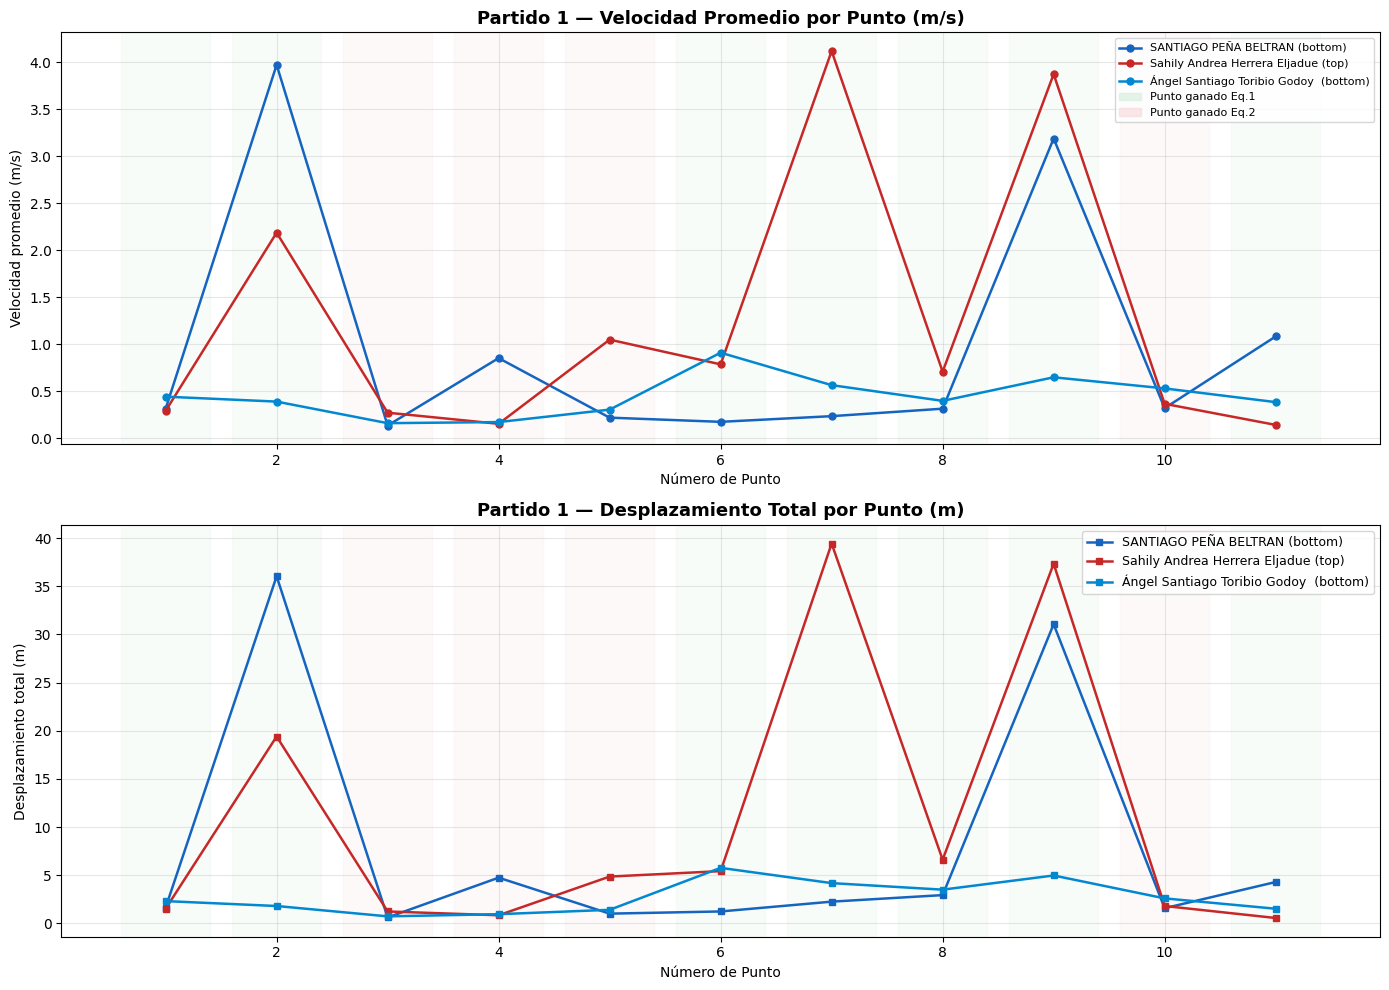

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for jugador in jugadores:
    datos = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num')
    color = color_map.get(jugador, 'gray')
    label = f"{jugador} ({equipos.get(jugador, '?')})"
    axes[0].plot(datos['punto_num'], datos['desplazamiento_total'],
                 marker='o', label=label, color=color, linewidth=1.8, markersize=5)
    axes[1].plot(datos['punto_num'], datos['velocidad_promedio'],
                 marker='s', label=label, color=color, linewidth=1.8, markersize=5)

# Marcar ganador de cada punto si está disponible
if ganador_por_punto:
    for punto, ganador in ganador_por_punto.items():
        bg = '#d4edda' if ganador == 'EQUIPO_1' else '#f8d7da'
        for ax in axes:
            ax.axvspan(punto - 0.4, punto + 0.4, alpha=0.15, color=bg, zorder=0)

axes[0].set_title(f'Partido {PARTIDO_NUM} — Desplazamiento Total por Punto (m)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de Punto')
axes[0].set_ylabel('Desplazamiento total (m)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title(f'Partido {PARTIDO_NUM} — Velocidad Promedio por Punto (m/s, incluye ceros)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de Punto')
axes[1].set_ylabel('Velocidad promedio (m/s)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

if ganador_por_punto:
    leyenda_eq1 = mpatches.Patch(color='#d4edda', alpha=0.6, label='Punto ganado Eq.1')
    leyenda_eq2 = mpatches.Patch(color='#f8d7da', alpha=0.6, label='Punto ganado Eq.2')
    axes[0].legend(handles=axes[0].get_legend_handles_labels()[0] + [leyenda_eq1, leyenda_eq2],
                   labels=axes[0].get_legend_handles_labels()[1] + ['Punto ganado Eq.1', 'Punto ganado Eq.2'],
                   fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
print(f'📋 Estadísticas Descriptivas — Partido {PARTIDO_NUM}\n')
print('Desplazamiento Total (m) — variable principal del forecasting:')
stats_vel = (
    serie_temporal.groupby('player_name')['desplazamiento_total']
    .agg(Media='mean', Std='std', Min='min', Max='max', Puntos='count')
    .round(3)
)
print(stats_vel.to_string())

print('
Velocidad Promedio (m/s, incluye ceros) — actividad media por punto:')
stats_dis = (
    serie_temporal.groupby('player_name')['velocidad_promedio']
    .agg(Media='mean', Std='std', Min='min', Max='max')
    .round(2)
)
print(stats_dis.to_string())

# Si hay datos del formulario: mostrar estado físico de los jugadores
if df_jugadores_info is not None:
    jugadores_info_filtrado = df_jugadores_info[
        df_jugadores_info['NOMBRE'].isin(jugadores)
    ][['NOMBRE', 'EDAD', 'ESTADO_FISICO', 'FRECUENCIA_DEPORTE', 'ESTATURA', 'TALLA', 'Win_Rate']]
    if not jugadores_info_filtrado.empty:
        print('\n📋 Datos físicos y rendimiento (de encuesta):')
        print(jugadores_info_filtrado.to_string(index=False))

📋 Estadísticas Descriptivas — Partido 1

Velocidad Promedio (m/s):
                               Media    Std    Min    Max  Puntos
player_name                                                      
SANTIAGO PEÑA BELTRAN          0.984  1.330  0.136  3.974      11
Sahily Andrea Herrera Eljadue  1.269  1.471  0.143  4.121      11
Ángel Santiago Toribio Godoy   0.447  0.215  0.161  0.911      11

Desplazamiento Total (m):
                               Media    Std   Min    Max
player_name                                             
SANTIAGO PEÑA BELTRAN           7.95  12.77  0.62  36.03
Sahily Andrea Herrera Eljadue  10.83  14.63  0.57  39.43
Ángel Santiago Toribio Godoy    2.71   1.68  0.74   5.77

📋 Datos físicos y rendimiento (de encuesta):
                       NOMBRE  EDAD ESTADO_FISICO FRECUENCIA_DEPORTE  ESTATURA  TALLA  Win_Rate
        SANTIAGO PEÑA BELTRAN    19       Regular          3-4 veces     176.0   80.0  0.511628
Sahily Andrea Herrera Eljadue    18       Regular    

## 🏃 SECCIÓN 3B — Datos Físicos vs Tendencia de Fatiga
*(Cruce entre `Data_Jugadores` y la pendiente de fatiga calculada en **todos** los partidos)*

Calculamos la pendiente de regresión lineal (desplazamiento → punto) para cada jugador en cada partido,
promediamos por jugador y lo cruzamos con `ESTADO_FISICO`, `FRECUENCIA_DEPORTE` y `Win_Rate`.

> Pendiente negativa = jugador se fatiga (baja desplazamiento conforme avanzan los puntos).
> Pendiente positiva = jugador acelera su ritmo (poco frecuente).

✅ 27 jugadores cruzados

                           NOMBRE  pendiente_media ESTADO_FISICO   FRECUENCIA_DEPORTE  Win_Rate
        Juan Esteban Bustos Marín        -1.274267         Bueno            1-2 veces  0.463415
     Juan sebastian melo gonzalez        -0.287271       Regular            1-2 veces  0.634615
        Alejandra Salazar Galeano        -0.204540       Regular            1-2 veces  0.380952
        Alejandra Salazar Galeano        -0.204540         Bueno              0 veces  0.380952
   Luis Felipe Cuellar Santamaria        -0.106310       Regular No practico deportes  0.434783
               Juan David Quitian        -0.087665     Excelente       Más de 4 veces  0.456140
                Isabella Buitrago        -0.032273         Bueno            3-4 veces  0.512195
                Sofia Daza García        -0.024401       Regular            1-2 veces  0.461538
                        Pia Aroor        -0.018152         Bueno            3-4 veces  0.239130
               

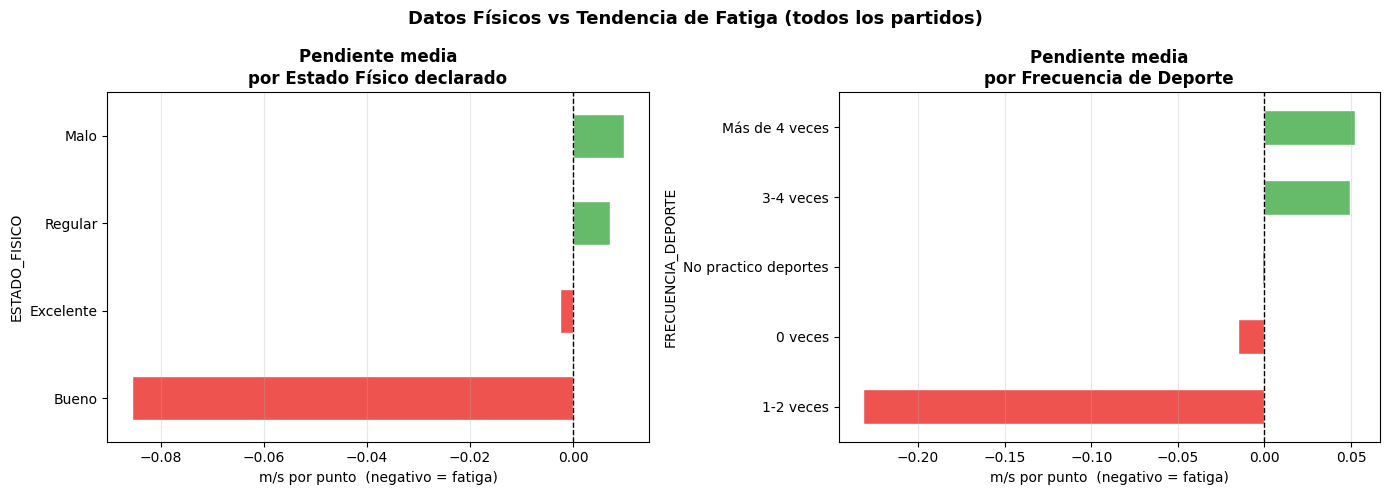

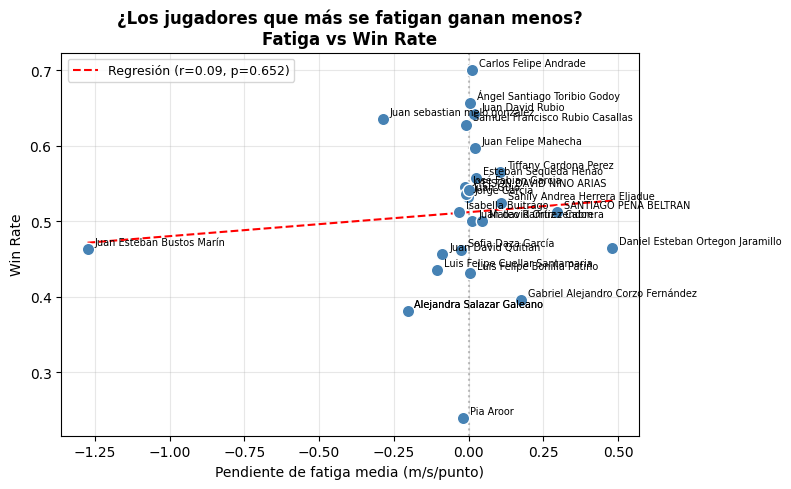


💡 Interpretación:
  • Pendiente más negativa = se fatiga más rápido
  • Si ESTADO_FISICO alto tiene pendiente menos negativa -> condición real en datos
  • Si r < 0 en Win Rate -> a mayor fatiga, menor Win Rate


In [11]:
if df_jugadores_info is None:
    print('\u26a0\ufe0f  Data_Jugadores no disponible.')
else:
    # Pendiente por jugador en todos los partidos
    _pends = []
    for _pid in sorted(df_raw['partido'].unique()):
        _dfp = df_raw[
            (df_raw['partido'] == _pid) &
            (~df_raw['player_name'].str.match(r'^Player_\d+$', na=False)) &
            (df_raw['player_speed_mps'] <= VEL_MAX_MS)
        ]
        _stp = (
            _dfp.groupby(['punto', 'player_name'])
            .agg(desplazamiento_total=('player_displacement', 'sum'))
            .reset_index()
            .sort_values(['player_name', 'punto'])
        )
        for _jug in _stp['player_name'].unique():
            _d = _stp[_stp['player_name'] == _jug].sort_values('punto')
            _x, _y = _d['punto'].values, _d['desplazamiento_total'].values
            if len(_x) >= 3:
                _sl, _, _r, _p, _ = stats.linregress(_x, _y)
                _pends.append({'partido': _pid, 'NOMBRE': _jug,
                               'pendiente': _sl, 'p_valor': _p, 'r2': _r**2})

    df_pends_all = pd.DataFrame(_pends)

    df_pend_jug = (
        df_pends_all.groupby('NOMBRE')
        .agg(pendiente_media=('pendiente', 'mean'),
             n_partidos=('partido', 'count'))
        .reset_index()
    )

    _cols_jug = [c for c in ['NOMBRE', 'ESTADO_FISICO', 'FRECUENCIA_DEPORTE', 'EDAD', 'Win_Rate']
                 if c in df_jugadores_info.columns]
    df_merged_jug = df_pend_jug.merge(df_jugadores_info[_cols_jug], on='NOMBRE', how='inner')

    if df_merged_jug.empty:
        print('\u26a0\ufe0f  Sin coincidencias de nombres entre CSV y Data_Jugadores.')
        print('   Nombres CSV       :', sorted(df_pend_jug['NOMBRE'].tolist()))
        print('   Nombres formulario:', sorted(df_jugadores_info['NOMBRE'].tolist()))
    else:
        print(f'\u2705 {len(df_merged_jug)} jugadores cruzados\n')
        _show = [c for c in ['NOMBRE','pendiente_media','ESTADO_FISICO','FRECUENCIA_DEPORTE','Win_Rate']
                 if c in df_merged_jug.columns]
        print(df_merged_jug[_show].sort_values('pendiente_media').to_string(index=False))

        fig_3b, ax_3b = plt.subplots(1, 2, figsize=(14, 5))

        if 'ESTADO_FISICO' in df_merged_jug.columns:
            _ef = df_merged_jug.groupby('ESTADO_FISICO')['pendiente_media'].mean().sort_values()
            _ef.plot(kind='barh', ax=ax_3b[0],
                     color=['#ef5350' if v < 0 else '#66bb6a' for v in _ef], edgecolor='white')
            ax_3b[0].axvline(0, color='black', lw=1, ls='--')
            ax_3b[0].set_title('Pendiente media\npor Estado F\u00edsico declarado', fontweight='bold')
            ax_3b[0].set_xlabel('m/punto  (negativo = fatiga)')
            ax_3b[0].grid(True, alpha=0.3, axis='x')
        else:
            ax_3b[0].set_visible(False)

        if 'FRECUENCIA_DEPORTE' in df_merged_jug.columns:
            _fd = df_merged_jug.groupby('FRECUENCIA_DEPORTE')['pendiente_media'].mean().sort_values()
            _fd.plot(kind='barh', ax=ax_3b[1],
                     color=['#ef5350' if v < 0 else '#66bb6a' for v in _fd], edgecolor='white')
            ax_3b[1].axvline(0, color='black', lw=1, ls='--')
            ax_3b[1].set_title('Pendiente media\npor Frecuencia de Deporte', fontweight='bold')
            ax_3b[1].set_xlabel('m/punto  (negativo = fatiga)')
            ax_3b[1].grid(True, alpha=0.3, axis='x')
        else:
            ax_3b[1].set_visible(False)

        fig_3b.suptitle('Datos F\u00edsicos vs Tendencia de Fatiga (todos los partidos)',
                        fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

        if 'Win_Rate' in df_merged_jug.columns and df_merged_jug['Win_Rate'].notna().sum() >= 3:
            _valid = df_merged_jug[['pendiente_media', 'Win_Rate']].dropna()
            fig_wr, ax_wr = plt.subplots(figsize=(8, 5))
            ax_wr.scatter(_valid['pendiente_media'], _valid['Win_Rate'],
                          s=80, color='steelblue', edgecolors='white', zorder=3)
            for _, _row in df_merged_jug.dropna(subset=['pendiente_media', 'Win_Rate']).iterrows():
                ax_wr.annotate(_row['NOMBRE'], (_row['pendiente_media'], _row['Win_Rate']),
                               textcoords='offset points', xytext=(5, 3), fontsize=7)
            if len(_valid) >= 3:
                _sl_wr, _int_wr, _r_wr, _p_wr, _ = stats.linregress(
                    _valid['pendiente_media'], _valid['Win_Rate'])
                _xl = np.linspace(_valid['pendiente_media'].min(), _valid['pendiente_media'].max(), 50)
                ax_wr.plot(_xl, _sl_wr * _xl + _int_wr, 'r--', lw=1.5,
                           label=f'Regresi\u00f3n (r={_r_wr:.2f}, p={_p_wr:.3f})')
                ax_wr.legend(fontsize=9)
            ax_wr.axvline(0, color='gray', ls=':', alpha=0.5)
            ax_wr.set_xlabel('Pendiente de fatiga media (m/punto)')
            ax_wr.set_ylabel('Win Rate')
            ax_wr.set_title('\u00bfLos jugadores que m\u00e1s se fatigan ganan menos?\nFatiga vs Win Rate',
                            fontweight='bold')
            ax_wr.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

        print('\n\U0001f4a1 Interpretaci\u00f3n:')
        print('  \u2022 Pendiente m\u00e1s negativa = se fatiga m\u00e1s r\u00e1pido')
        print('  \u2022 Si ESTADO_FISICO alto tiene pendiente menos negativa -> condici\u00f3n real en datos')
        print('  \u2022 Si r < 0 en Win Rate -> a mayor fatiga, menor Win Rate')


## 📈 SECCIÓN 4 — Promedios Móviles (SMA) y Suavizamiento Exponencial (EMA)
*(Grupo 12: Promedios Móviles y Suavizamiento Exponencial)*

- **SMA-3 / SMA-5**: Promedio Móvil Simple con ventana de 3 y 5 puntos. Suaviza el ruido manteniendo la tendencia real.
- **EMA-3 / EMA-5**: Media Móvil Exponencial — da más peso a observaciones recientes, reacciona más rápido a cambios.

> Si **SMA-5 cae sostenidamente** hacia el final del partido → hay evidencia de fatiga real, no solo variabilidad puntual.

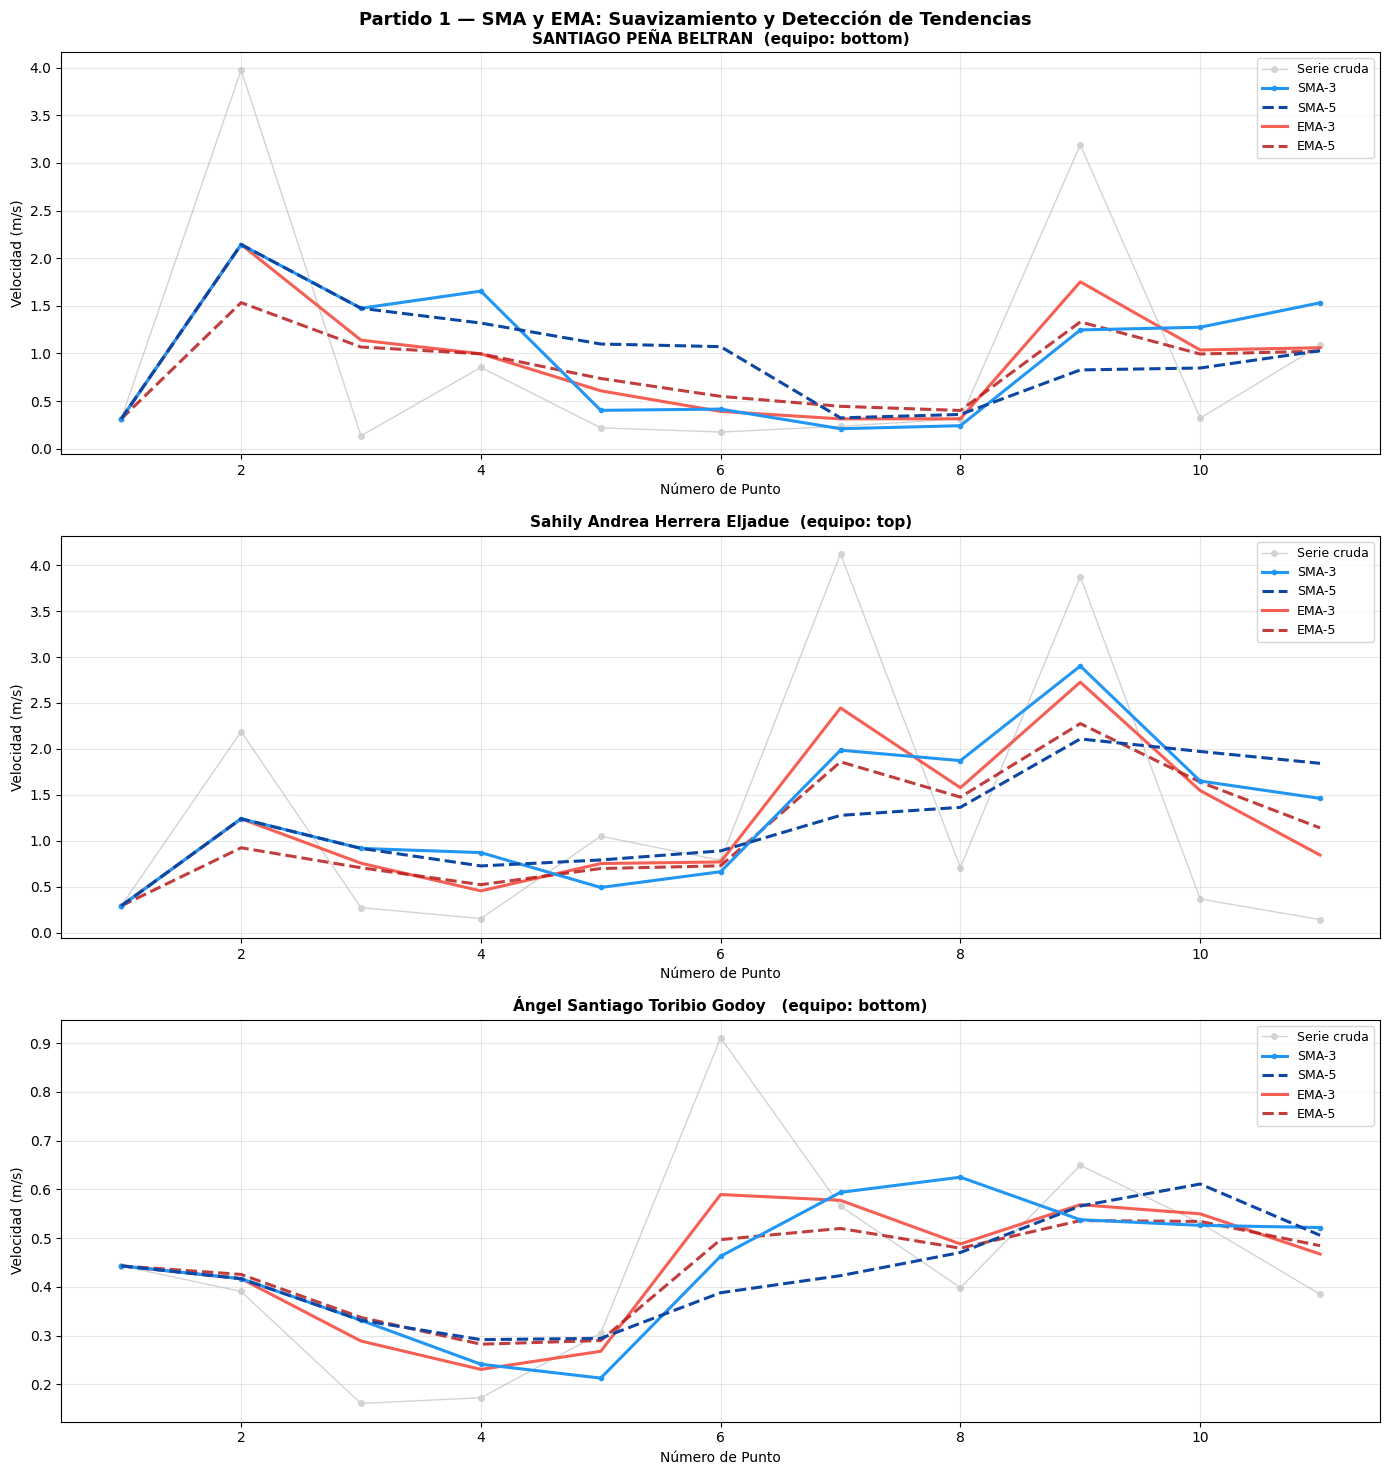


💡 Interpretación:
  • SMA-5 descendente al final → tendencia de fatiga sostenida
  • EMA cae antes que SMA-5   → el jugador perdió ritmo de golpe (reacción rápida)
  • Sin tendencia clara       → rendimiento estable o altamente variable


In [12]:
# ---- Calcular SMA y EMA por jugador -------------------------
serie_temporal = serie_temporal.sort_values(['player_name', 'punto_num'])

for jugador in jugadores:
    mask = serie_temporal['player_name'] == jugador
    s = serie_temporal.loc[mask, 'desplazamiento_total']
    serie_temporal.loc[mask, 'SMA3'] = s.rolling(window=3, min_periods=1).mean()
    serie_temporal.loc[mask, 'SMA5'] = s.rolling(window=5, min_periods=1).mean()
    serie_temporal.loc[mask, 'EMA3'] = s.ewm(span=3, adjust=False).mean()
    serie_temporal.loc[mask, 'EMA5'] = s.ewm(span=5, adjust=False).mean()

# ---- Visualización ------------------------------------------
n = len(jugadores)
fig, axes = plt.subplots(n, 1, figsize=(14, 5 * n))
if n == 1:
    axes = [axes]

for ax, jugador in zip(axes, jugadores):
    d = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num')
    ax.plot(d['punto_num'], d['desplazamiento_total'],
            'o-', color='lightgray', label='Desplazamiento por punto', lw=1, ms=4, zorder=1)
    ax.plot(d['punto_num'], d['SMA3'],
            '.-', color='#2196F3', label='SMA-3', lw=2.2, zorder=3)
    ax.plot(d['punto_num'], d['SMA5'],
            '--', color='#0D47A1', label='SMA-5', lw=2.2, zorder=3)
    ax.plot(d['punto_num'], d['EMA3'],
            '-',  color='#F44336', label='EMA-3', lw=2.2, alpha=0.85, zorder=2)
    ax.plot(d['punto_num'], d['EMA5'],
            '--', color='#B71C1C', label='EMA-5', lw=2.2, alpha=0.85, zorder=2)
    ax.set_title(f'{jugador}  (equipo: {equipos.get(jugador, "?")})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Número de Punto')
    ax.set_ylabel('Desplazamiento (m)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Partido {PARTIDO_NUM} — SMA y EMA — Desplazamiento total por punto (suavizamiento)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Interpretación:')
print('  • SMA-5 descendente al final → tendencia de fatiga sostenida')
print('  • EMA cae antes que SMA-5   → el jugador perdió ritmo de golpe (reacción rápida)')
print('  • Sin tendencia clara       → rendimiento estable o altamente variable')

## ⚡ SECCIÓN 5 — Golden / Death Cross Táctico

Adaptación del concepto de trading al análisis deportivo:

| Evento | Condición | Interpretación |
|---|---|---|
| ☠ **Death Cross** | SMA-3 cruza hacia abajo la SMA-5 | Inicio de fatiga / caída de ritmo |
| ⭐ **Golden Cross** | SMA-3 cruza hacia arriba la SMA-5 | Recuperación de rendimiento |

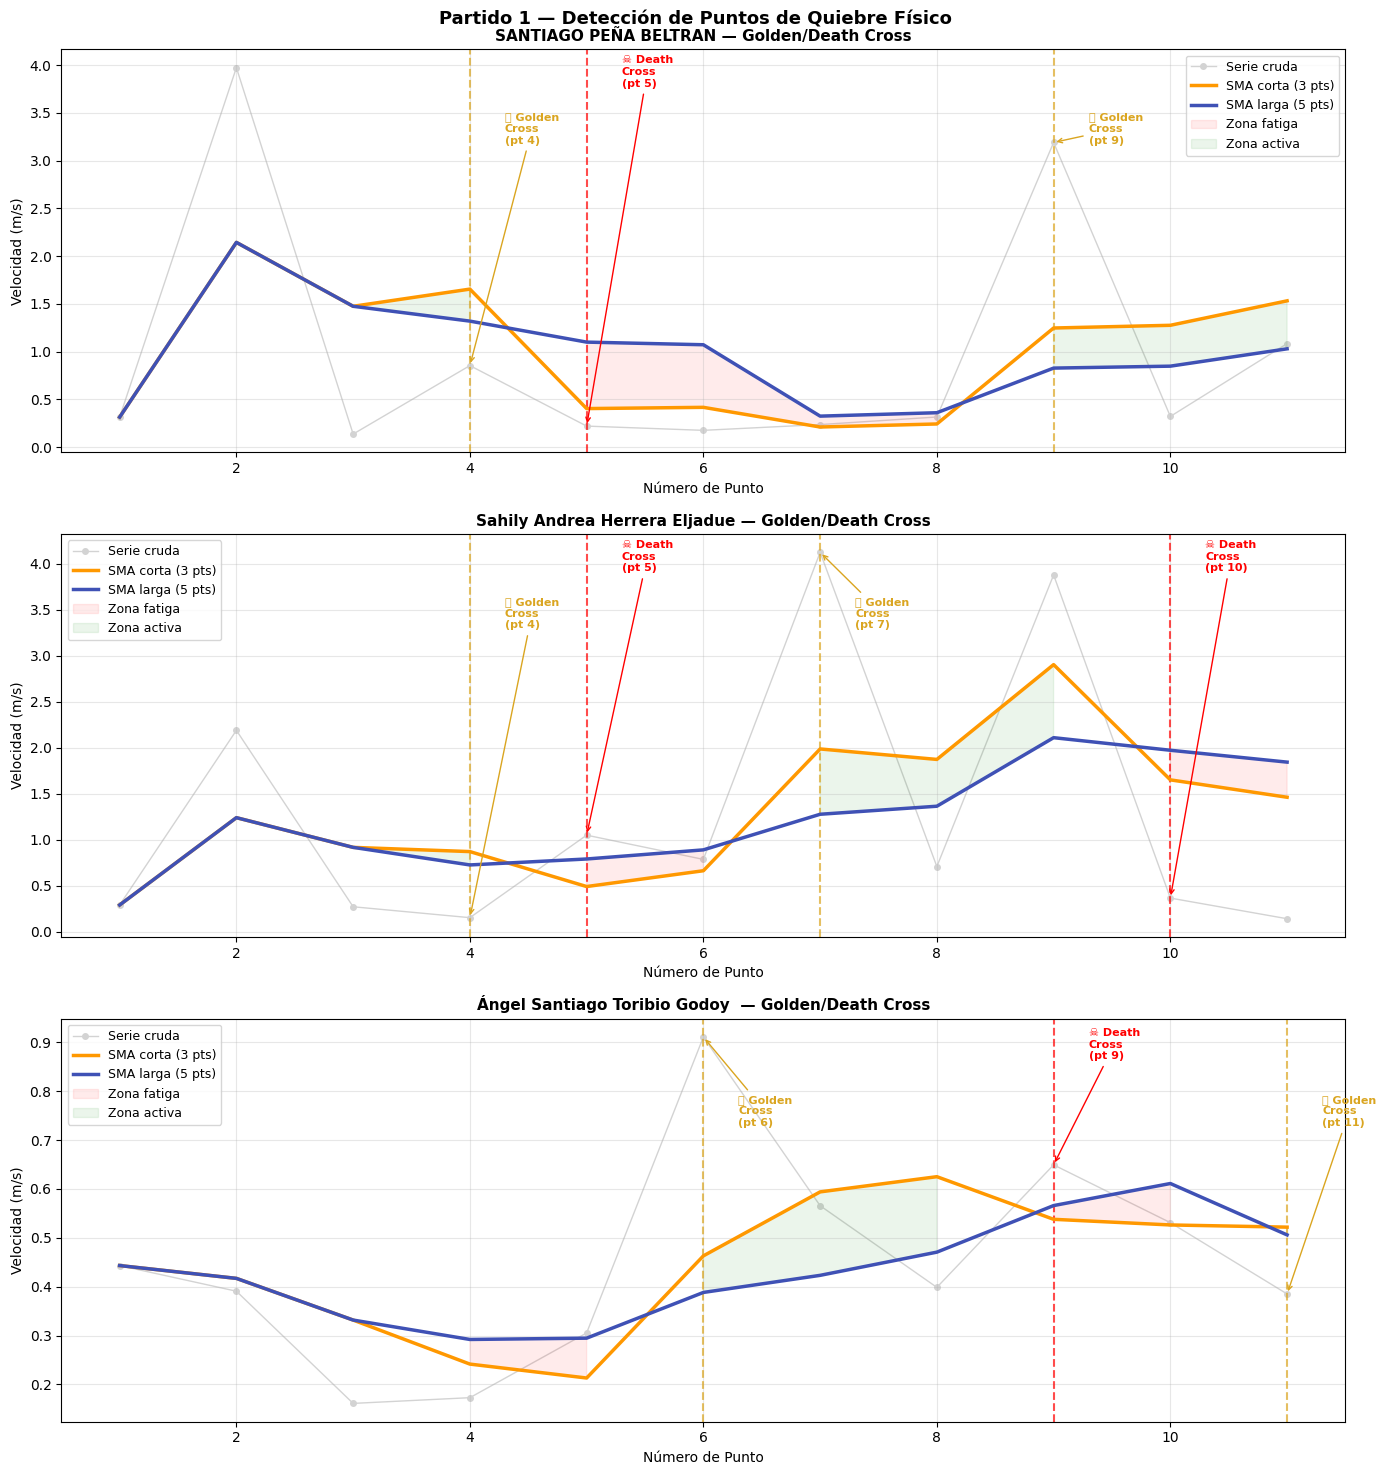


💡 Interpretación:
  ☠ Death Cross: ritmo reciente (SMA-3) cae bajo el promedio general (SMA-5) → fatiga acumulada real
  ⭐ Golden Cross: ritmo reciente supera el promedio general → recuperación de intensidad


In [13]:
n = len(jugadores)
fig, axes = plt.subplots(n, 1, figsize=(14, 5 * n))
if n == 1:
    axes = [axes]

for ax, jugador in zip(axes, jugadores):
    d    = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num').copy()
    x    = d['punto_num'].values
    sma3 = d['SMA3'].values
    sma5 = d['SMA5'].values
    raw  = d['desplazamiento_total'].values

    ax.plot(x, raw,  'o-', color='lightgray',  label='Desplazamiento por punto',      lw=1,   ms=4,  zorder=1)
    ax.plot(x, sma3, '-',  color='#FF9800',    label='SMA corta (3 pts)', lw=2.5, zorder=3)
    ax.plot(x, sma5, '-',  color='#3F51B5',    label='SMA larga (5 pts)', lw=2.5, zorder=3)
    ax.fill_between(x, sma3, sma5,
                    where=(sma3 < sma5), color='red',   alpha=0.08, label='Zona fatiga')
    ax.fill_between(x, sma3, sma5,
                    where=(sma3 >= sma5), color='green', alpha=0.08, label='Zona activa')

    # Detectar y marcar cruces
    diff = sma3 - sma5
    y_max = max(raw) if len(raw) > 0 else 1.0
    for i in range(1, len(diff)):
        if np.isnan(diff[i-1]) or np.isnan(diff[i]):
            continue
        if diff[i-1] > 0 and diff[i] <= 0:
            ax.axvline(x=x[i], color='red', linestyle='--', alpha=0.7, lw=1.5)
            ax.annotate(f'☠ Death\nCross\n(pt {x[i]})',
                        xy=(x[i], raw[i]),
                        xytext=(x[i] + 0.3, y_max * 0.95),
                        fontsize=8, color='red', fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color='red', lw=1))
        elif diff[i-1] <= 0 and diff[i] > 0:
            ax.axvline(x=x[i], color='goldenrod', linestyle='--', alpha=0.7, lw=1.5)
            ax.annotate(f'⭐ Golden\nCross\n(pt {x[i]})',
                        xy=(x[i], raw[i]),
                        xytext=(x[i] + 0.3, y_max * 0.80),
                        fontsize=8, color='goldenrod', fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color='goldenrod', lw=1))

    ax.set_title(f'{jugador} — Golden/Death Cross', fontsize=11, fontweight='bold')
    ax.set_xlabel('Número de Punto')
    ax.set_ylabel('Desplazamiento (m)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Partido {PARTIDO_NUM} — Detección de Puntos de Quiebre Físico',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Interpretación:')
print('  ☠ Death Cross: ritmo reciente (SMA-3) cae bajo el promedio general (SMA-5) → fatiga acumulada real')
print('  ⭐ Golden Cross: ritmo reciente supera el promedio general → recuperación de intensidad')

## 🔀 SECCIÓN 6 — División Train / Test y Línea Base
*(Grupo 11: Evaluación de Modelos de Forecasting)*

Dividimos la serie de cada jugador en:
- **Train (70%)**: para ajustar el modelo
- **Test (30%)**: para evaluar la predicción

Métricas de evaluación:
- **MAE** (Mean Absolute Error): error promedio en m
- **RMSE** (Root Mean Squared Error): penaliza más los errores grandes

La **línea base naive** predice siempre el último valor conocido — es el piso mínimo que debe superar cualquier modelo.

In [14]:
def evaluar_modelo(y_true, y_pred, nombre='Modelo'):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'  {nombre:<40s} MAE: {mae:.4f} m  |  RMSE: {rmse:.4f} m')
    return {'modelo': nombre, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}


# 70/30 es la proporción estándar en evaluación de modelos de series temporales
SPLIT_RATIO = 0.70

resultados_globales = {}   # {jugador: [lista de dicts con métricas]}
indices_split       = {}   # {jugador: split_idx}

print(f'División train/test: {int(SPLIT_RATIO*100)}% / {int((1-SPLIT_RATIO)*100)}%\n')

for jugador in jugadores:
    datos = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num')
    n     = len(datos)
    split = max(int(n * SPLIT_RATIO), 2)
    train = datos['desplazamiento_total'].values[:split]
    test  = datos['desplazamiento_total'].values[split:]

    print(f'👤 {jugador}: {n} puntos → train={len(train)}, test={len(test)}')

    if len(test) == 0:
        print('   ⚠️  Sin puntos de test (mínimo 3 puntos totales para evaluar). Saltando.\n')
        continue

    indices_split[jugador] = split
    resultados_globales[jugador] = []

    # Baseline naive (último valor conocido)
    naive_pred = np.full(len(test), train[-1])
    resultados_globales[jugador].append(
        evaluar_modelo(test, naive_pred, 'Naive (último valor conocido)')
    )
    print()

División train/test: 70% / 30%

👤 SANTIAGO PEÑA BELTRAN: 11 puntos → train=7, test=4
  Naive (último valor conocido)            MAE: 0.9920 m/s  |  RMSE: 1.5383 m/s

👤 Sahily Andrea Herrera Eljadue: 11 puntos → train=7, test=4
  Naive (último valor conocido)            MAE: 2.8478 m/s  |  RMSE: 3.2261 m/s

👤 Ángel Santiago Toribio Godoy : 11 puntos → train=7, test=4
  Naive (último valor conocido)            MAE: 0.1165 m/s  |  RMSE: 0.1311 m/s



## 📉 SECCIÓN 7 — Suavizamiento Exponencial de Holt
*(Grupo 12 — como modelo de forecast)*

El **Suavizamiento Exponencial de Holt** (Doble Exponencial) captura nivel y tendencia lineal — apropiado para detectar caídas de rendimiento progresivas.

📉 Suavizamiento Exponencial de Holt

  Exp. Smoothing (Holt)                    MAE: 1.9055 m/s  |  RMSE: 2.2517 m/s
  Exp. Smoothing (Holt)                    MAE: 2.3114 m/s  |  RMSE: 2.5119 m/s
  Exp. Smoothing (Holt)                    MAE: 0.2353 m/s  |  RMSE: 0.2702 m/s


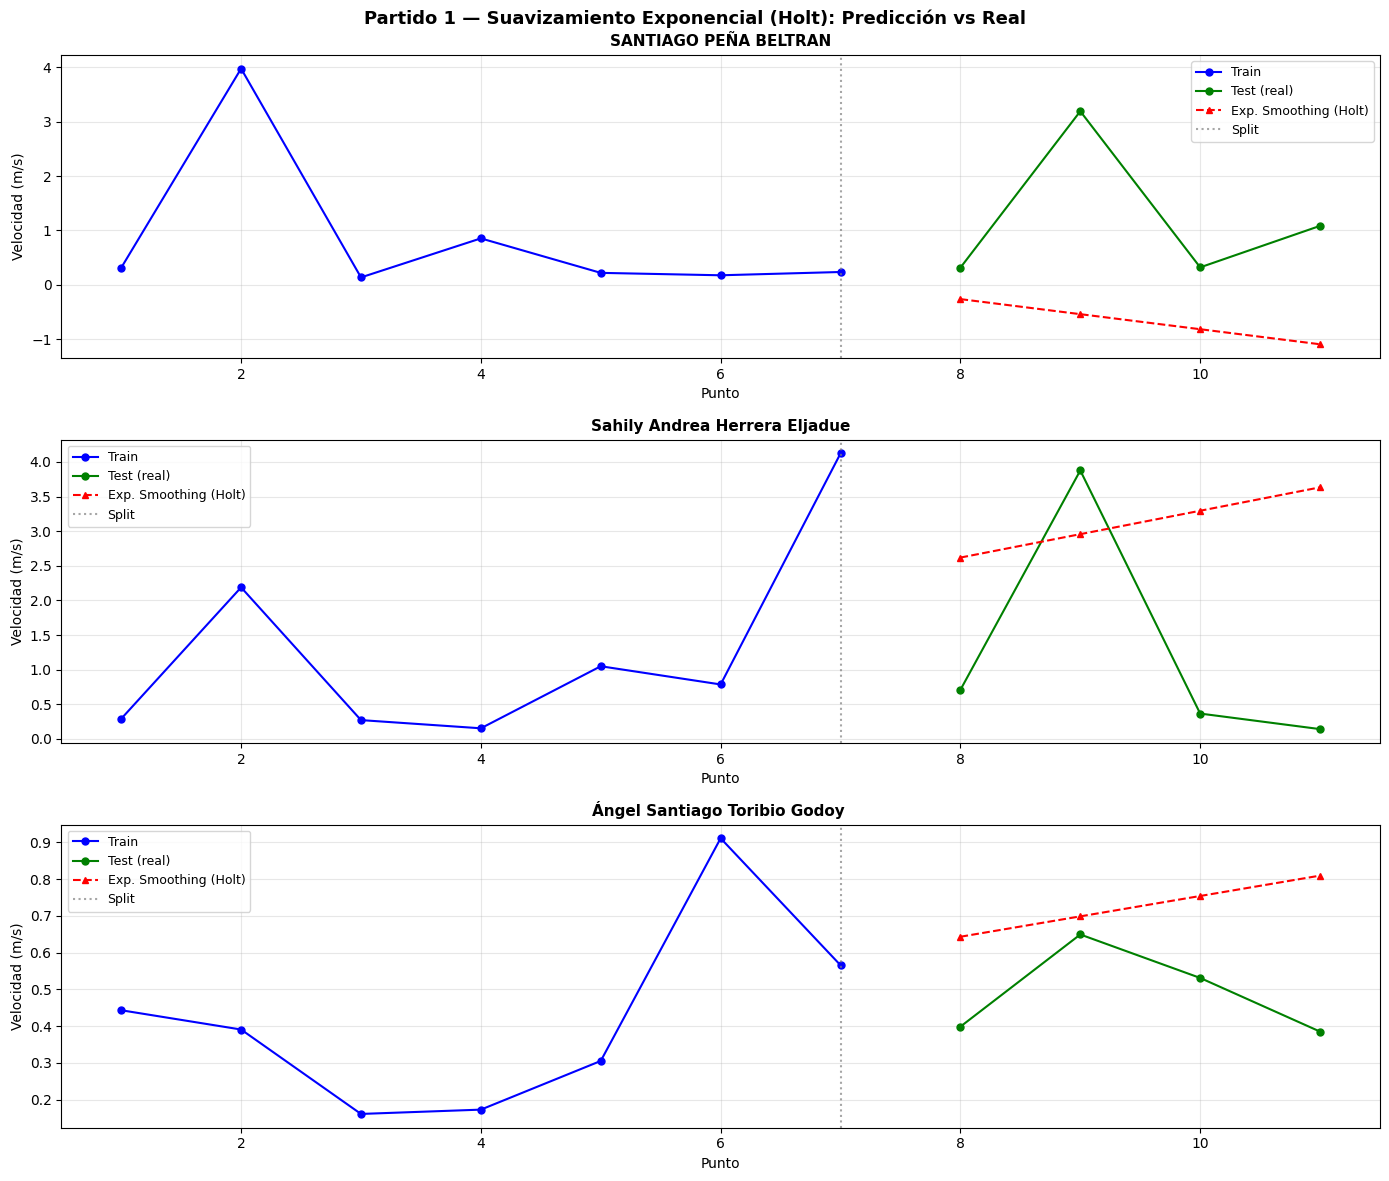

In [15]:
print('📉 Suavizamiento Exponencial de Holt\n')

jugadores_eval = list(resultados_globales.keys())
n_eval = len(jugadores_eval)
fig, axes = plt.subplots(n_eval, 1, figsize=(14, 4 * n_eval))
if n_eval == 1:
    axes = [axes]

for ax, jugador in zip(axes, jugadores_eval):
    datos  = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num')
    puntos = datos['punto_num'].values
    serie  = datos['desplazamiento_total'].values
    split  = indices_split[jugador]
    train, test = serie[:split], serie[split:]

    try:
        modelo_es = ExponentialSmoothing(
            train, trend='add', initialization_method='estimated'
        )
        fit_es  = modelo_es.fit(optimized=True)
        pred_es = fit_es.forecast(len(test))
        resultados_globales[jugador].append(
            evaluar_modelo(test, pred_es, 'Exp. Smoothing (Holt)')
        )
    except Exception as exc:
        print(f'  ⚠️  Error Exp. Smoothing para {jugador}: {exc}')
        pred_es = np.full(len(test), train[-1])

    ax.plot(puntos[:split], train,   'b-o', label='Train',                  ms=5)
    ax.plot(puntos[split:], test,    'g-o', label='Test (real)',             ms=5)
    ax.plot(puntos[split:], pred_es, 'r--^', label='Exp. Smoothing (Holt)', ms=5)
    ax.axvline(x=puntos[split - 1], color='gray', linestyle=':', alpha=0.7, label='Split')
    ax.set_title(f'{jugador}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Punto')
    ax.set_ylabel('Desplazamiento (m)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Partido {PARTIDO_NUM} — Suavizamiento Exponencial (Holt): Predicción vs Real',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔧 SECCIÓN 8 — ARIMA
*(Autoregressive Integrated Moving Average)*

**Pasos**:
1. Verificar estacionariedad con el **Test ADF** (Augmented Dickey-Fuller) → determina `d` automáticamente
2. Visualizar **ACF** y **PACF** → determina `p` y `q` automáticamente leyendo el primer lag significativo
3. Ajustar `ARIMA(p, d, q)` sobre entrenamiento y evaluar en prueba

> El orden `(p, d, q)` se calcula automáticamente para cada jugador a partir de sus datos.

> ⚠️ **Nota metodológica**: con series de 3–14 puntos, ARIMA es un modelo *demostrativo*. Los resultados indican tendencias, no predicciones robustas. SMA/EMA son más defendibles en series tan cortas.

🔍 Test de Estacionariedad (ADF) y orden ARIMA detectado automáticamente

  SANTIAGO PEÑA BELTRAN
    ADF p-value: 0.0015  → ✅ Estacionaria
    Orden detectado: ARIMA(1, 0, 0)

  Sahily Andrea Herrera Eljadue
    ADF p-value: 0.0304  → ✅ Estacionaria
    Orden detectado: ARIMA(1, 0, 0)

  Ángel Santiago Toribio Godoy 
    ADF p-value: 0.2215  → ⚠️  No estacionaria
    Orden detectado: ARIMA(1, 1, 0)



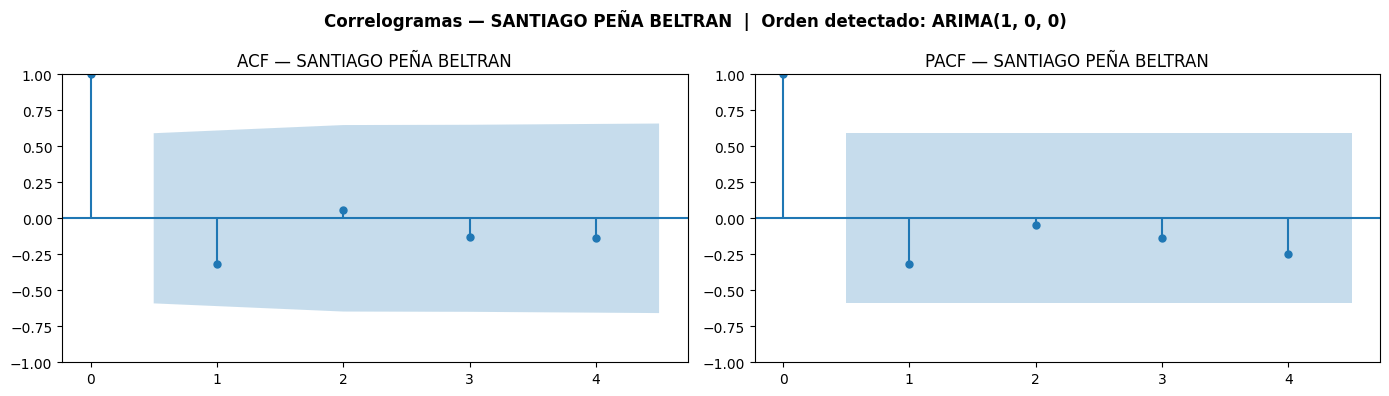

💡 Interpretación:
  • PACF: lag significativo fuera del intervalo sombreado → p
  • ACF:  lag significativo fuera del intervalo sombreado → q
  • Serie no estacionaria (ADF p > 0.05) → d = 1 (se diferencia una vez)


In [17]:
from statsmodels.tsa.stattools import pacf as pacf_fn, acf as acf_fn

def auto_arima_order(serie):
    """
    Determina automáticamente el orden ARIMA(p, d, q) para una serie.
    - d: test ADF (d=0 si estacionaria, d=1 si no)
    - p: primer lag significativo en PACF (componente AR)
    - q: primer lag significativo en ACF  (componente MA)
    """
    n = len(serie)
    if n < 5:
        return (1, 1, 0)

    # --- d: estacionariedad por ADF ---
    adf_pval = adfuller(serie)[1]
    d = 0 if adf_pval < 0.05 else 1

    # Diferenciar si es necesario
    s = np.diff(serie) if d == 1 else serie.copy()
    if len(s) < 4:
        return (1, d, 0)

    max_lags = min(5, len(s) // 2 - 1)
    if max_lags < 1:
        return (1, d, 0)

    ci = 1.96 / np.sqrt(len(s))   # intervalo de confianza 95%

    # --- p: primer lag significativo en PACF ---
    try:
        pacf_vals = pacf_fn(s, nlags=max_lags, method='ywm')
        p = 1
        for i in range(1, len(pacf_vals)):
            if abs(pacf_vals[i]) > ci:
                p = i
                break
    except Exception:
        p = 1

    # --- q: primer lag significativo en ACF ---
    try:
        acf_vals = acf_fn(s, nlags=max_lags, fft=True)
        q = 0
        for i in range(1, len(acf_vals)):
            if abs(acf_vals[i]) > ci:
                q = i
                break
    except Exception:
        q = 0

    return (p, d, q)


# ---- Test ADF + ACF/PACF visuales ---------------------------
print('🔍 Test de Estacionariedad (ADF) y orden ARIMA detectado automáticamente\n')

ordenes_arima = {}   # {jugador: (p, d, q)}

for jugador in jugadores_eval:
    datos_j = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num')
    serie_j = datos_j['desplazamiento_total'].values
    if len(serie_j) < 5:
        print(f'  {jugador}: serie muy corta, se usará ARIMA(1,1,0) por defecto')
        ordenes_arima[jugador] = (1, 1, 0)
        continue
    adf_res = adfuller(serie_j)
    estacionaria = '✅ Estacionaria' if adf_res[1] < 0.05 else '⚠️  No estacionaria'
    orden = auto_arima_order(serie_j)
    ordenes_arima[jugador] = orden
    print(f'  {jugador}')
    print(f'    ADF p-value: {adf_res[1]:.4f}  → {estacionaria}')
    print(f'    Orden detectado: ARIMA{orden}')
    print()

# Gráficos ACF/PACF del primer jugador con suficientes datos
jugador_demo = next(
    (j for j in jugadores_eval
     if len(serie_temporal[serie_temporal['player_name'] == j]) >= 5),
    None
)
if jugador_demo:
    serie_demo = serie_temporal[
        serie_temporal['player_name'] == jugador_demo
    ].sort_values('punto_num')['desplazamiento_total'].values
    max_lags = min(10, len(serie_demo) // 2 - 1)
    if max_lags >= 1:
        fig, axes_acf = plt.subplots(1, 2, figsize=(14, 4))
        plot_acf(serie_demo,  lags=max_lags, ax=axes_acf[0],
                 title=f'ACF — {jugador_demo}')
        plot_pacf(serie_demo, lags=max_lags, ax=axes_acf[1],
                  title=f'PACF — {jugador_demo}', method='ywm')
        plt.suptitle(f'Correlogramas — {jugador_demo}  |  Orden detectado: ARIMA{ordenes_arima[jugador_demo]}',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print('💡 Interpretación:')\
        
        print('  • PACF: lag significativo fuera del intervalo sombreado → p')
        print('  • ACF:  lag significativo fuera del intervalo sombreado → q')
        print('  • Serie no estacionaria (ADF p > 0.05) → d = 1 (se diferencia una vez)')

🔧 Ajustando ARIMA por jugador (orden detectado automáticamente)

  ARIMA(1, 0, 0)                           MAE: 0.9610 m/s  |  RMSE: 1.2656 m/s
  ✅ SANTIAGO PEÑA BELTRAN ARIMA(1, 0, 0) → MAE=0.9610 | RMSE=1.2656
  ARIMA(1, 0, 0)                           MAE: 1.1663 m/s  |  RMSE: 1.3476 m/s
  ✅ Sahily Andrea Herrera Eljadue ARIMA(1, 0, 0) → MAE=1.1663 | RMSE=1.3476
  ARIMA(1, 1, 0)                           MAE: 0.1524 m/s  |  RMSE: 0.1796 m/s
  ✅ Ángel Santiago Toribio Godoy  ARIMA(1, 1, 0) → MAE=0.1524 | RMSE=0.1796


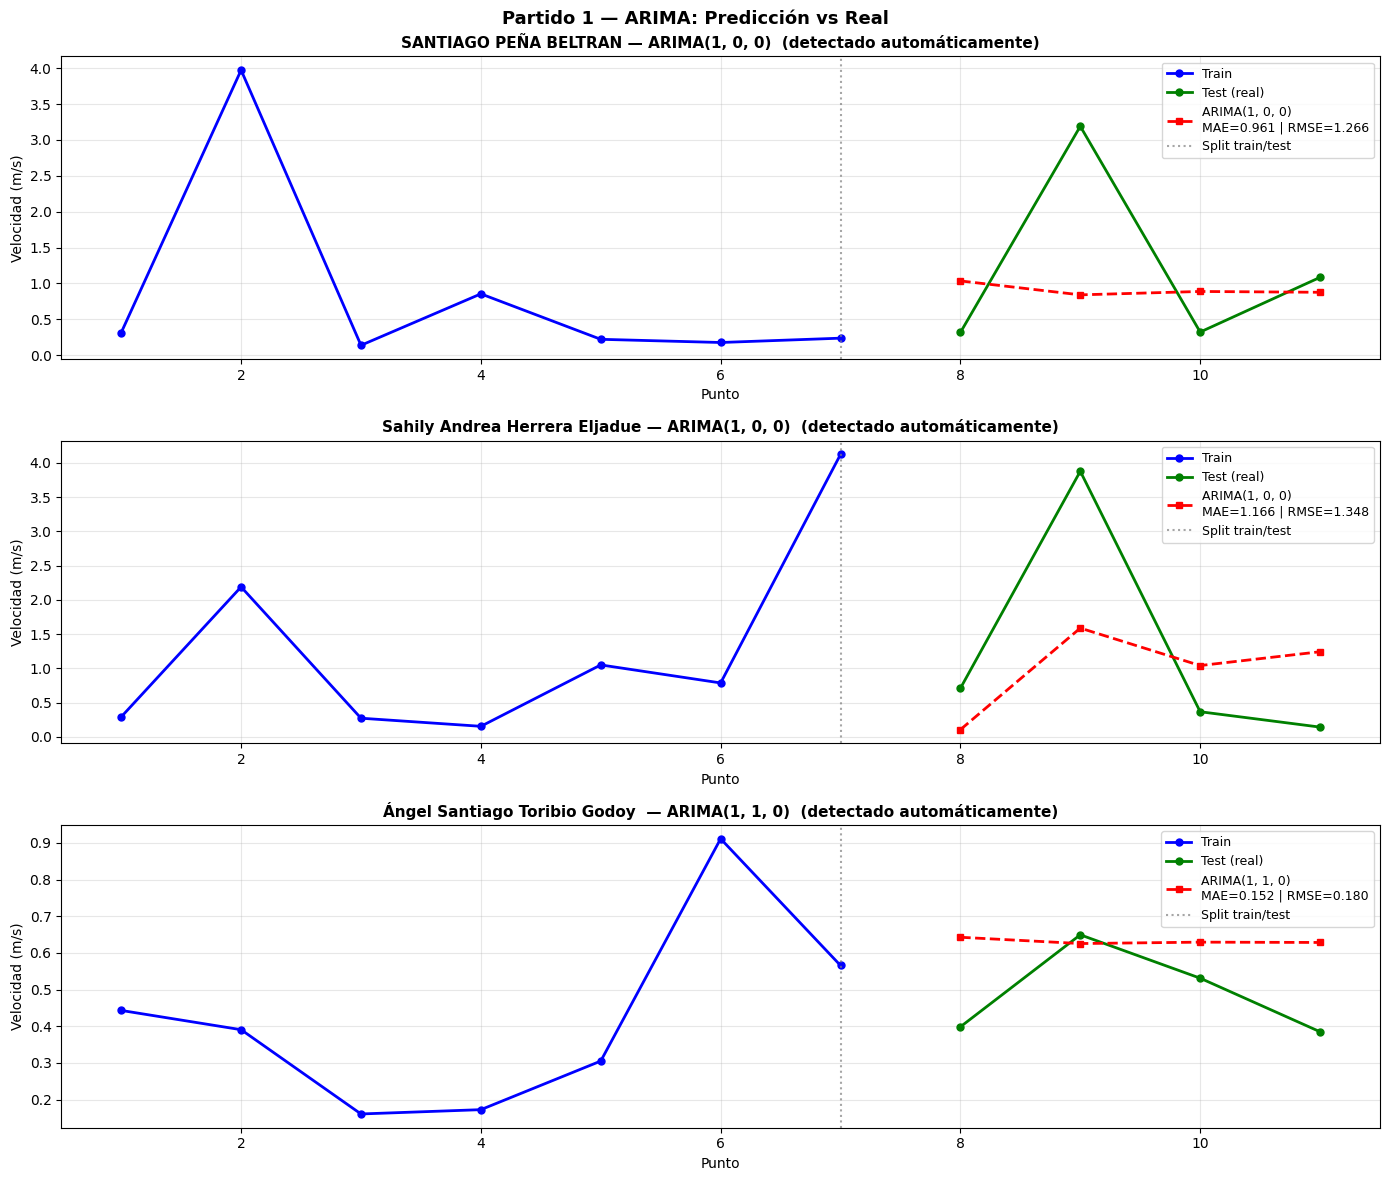

In [18]:
print('🔧 Ajustando ARIMA por jugador (orden detectado automáticamente)\n')

n_eval = len(jugadores_eval)
fig, axes = plt.subplots(n_eval, 1, figsize=(14, 4 * n_eval))
if n_eval == 1:
    axes = [axes]

for ax, jugador in zip(axes, jugadores_eval):
    datos  = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num')
    puntos = datos['punto_num'].values
    serie  = datos['desplazamiento_total'].values
    split  = indices_split[jugador]
    train, test = serie[:split], serie[split:]

    orden = ordenes_arima.get(jugador, (1, 1, 0))

    # ---- Protección series cortas ----
    if len(train) < 3:
        print(f'  ⚠️  {jugador}: train muy corto ({len(train)} puntos), saltando ARIMA.')
        pred_arima = np.full(len(test), train[-1] if len(train) > 0 else 0)
        ax.set_visible(False)
        continue

    if len(test) < 1:
        print(f'  ⚠️  {jugador}: sin puntos de test, saltando.')
        ax.set_visible(False)
        continue

    # Ajustar orden para no exceder tamaño de serie
    p, d, q = orden
    max_params = max(1, len(train) // 3)
    orden = (min(p, max_params), d, min(q, max_params))

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            fit_arima  = ARIMA(train, order=orden).fit()
        pred_arima = np.array(fit_arima.forecast(steps=len(test)))
        mae_ar  = mean_absolute_error(test, pred_arima)
        rmse_ar = np.sqrt(mean_squared_error(test, pred_arima))
        resultados_globales[jugador].append(
            evaluar_modelo(test, pred_arima, f'ARIMA{orden}')
        )
        print(f'  ✅ {jugador} ARIMA{orden} → MAE={mae_ar:.4f} | RMSE={rmse_ar:.4f}')
    except Exception as exc:
        print(f'  ❌ Error ARIMA{orden} para {jugador}: {str(exc)[:120]}')
        pred_arima = np.full(len(test), train[-1])
        mae_ar  = mean_absolute_error(test, pred_arima)
        rmse_ar = np.sqrt(mean_squared_error(test, pred_arima))

    ax.plot(puntos[:split], train,      'b-o',  label='Train',           ms=5, lw=2)
    ax.plot(puntos[split:], test,       'g-o',  label='Test (real)',      ms=5, lw=2)
    ax.plot(puntos[split:], pred_arima, 'r--s', label=f'ARIMA{orden}\nMAE={mae_ar:.3f} | RMSE={rmse_ar:.3f}', ms=5, lw=2)
    ax.axvline(x=puntos[split - 1], color='gray', linestyle=':', alpha=0.7, label='Split train/test')
    ax.set_title(f'{jugador} — ARIMA{orden}  (detectado automáticamente)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Punto')
    ax.set_ylabel('Desplazamiento (m)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Partido {PARTIDO_NUM} — ARIMA: Predicción vs Real',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔮 SECCIÓN 9 — Prophet de Meta
*(Grupo 13: Prophet de Meta)*

**Prophet** captura tendencias y genera un forecast con **bandas de incertidumbre**. Aquí lo usamos para:
1. Modelar la tendencia de fatiga a lo largo del partido
2. Extrapolar el rendimiento **más allá de los puntos jugados**
3. Generar un "¿cuándo esperamos que colapse el ritmo?"

> Si Prophet no está instalado: `pip install prophet`

> ⚠️ **Nota metodológica**: Prophet requiere al menos ~20 observaciones para capturar tendencias y estacionalidad. Con < 15 puntos por jugador, se usa como modelo *demostrativo* de la metodología, no para conclusiones predictivas fuertes.

10:20:38 - cmdstanpy - INFO - Chain [1] start processing


🔮 Prophet de Meta — Partido 1



10:20:39 - cmdstanpy - INFO - Chain [1] done processing
10:20:39 - cmdstanpy - INFO - Chain [1] start processing
10:20:39 - cmdstanpy - INFO - Chain [1] done processing
10:20:39 - cmdstanpy - INFO - Chain [1] start processing
10:20:39 - cmdstanpy - INFO - Chain [1] done processing


  Prophet (Meta)                           MAE: 1.8932 m/s  |  RMSE: 2.2410 m/s
  Prophet (Meta)                           MAE: 2.3112 m/s  |  RMSE: 2.5115 m/s
  Prophet (Meta)                           MAE: 0.2343 m/s  |  RMSE: 0.2693 m/s


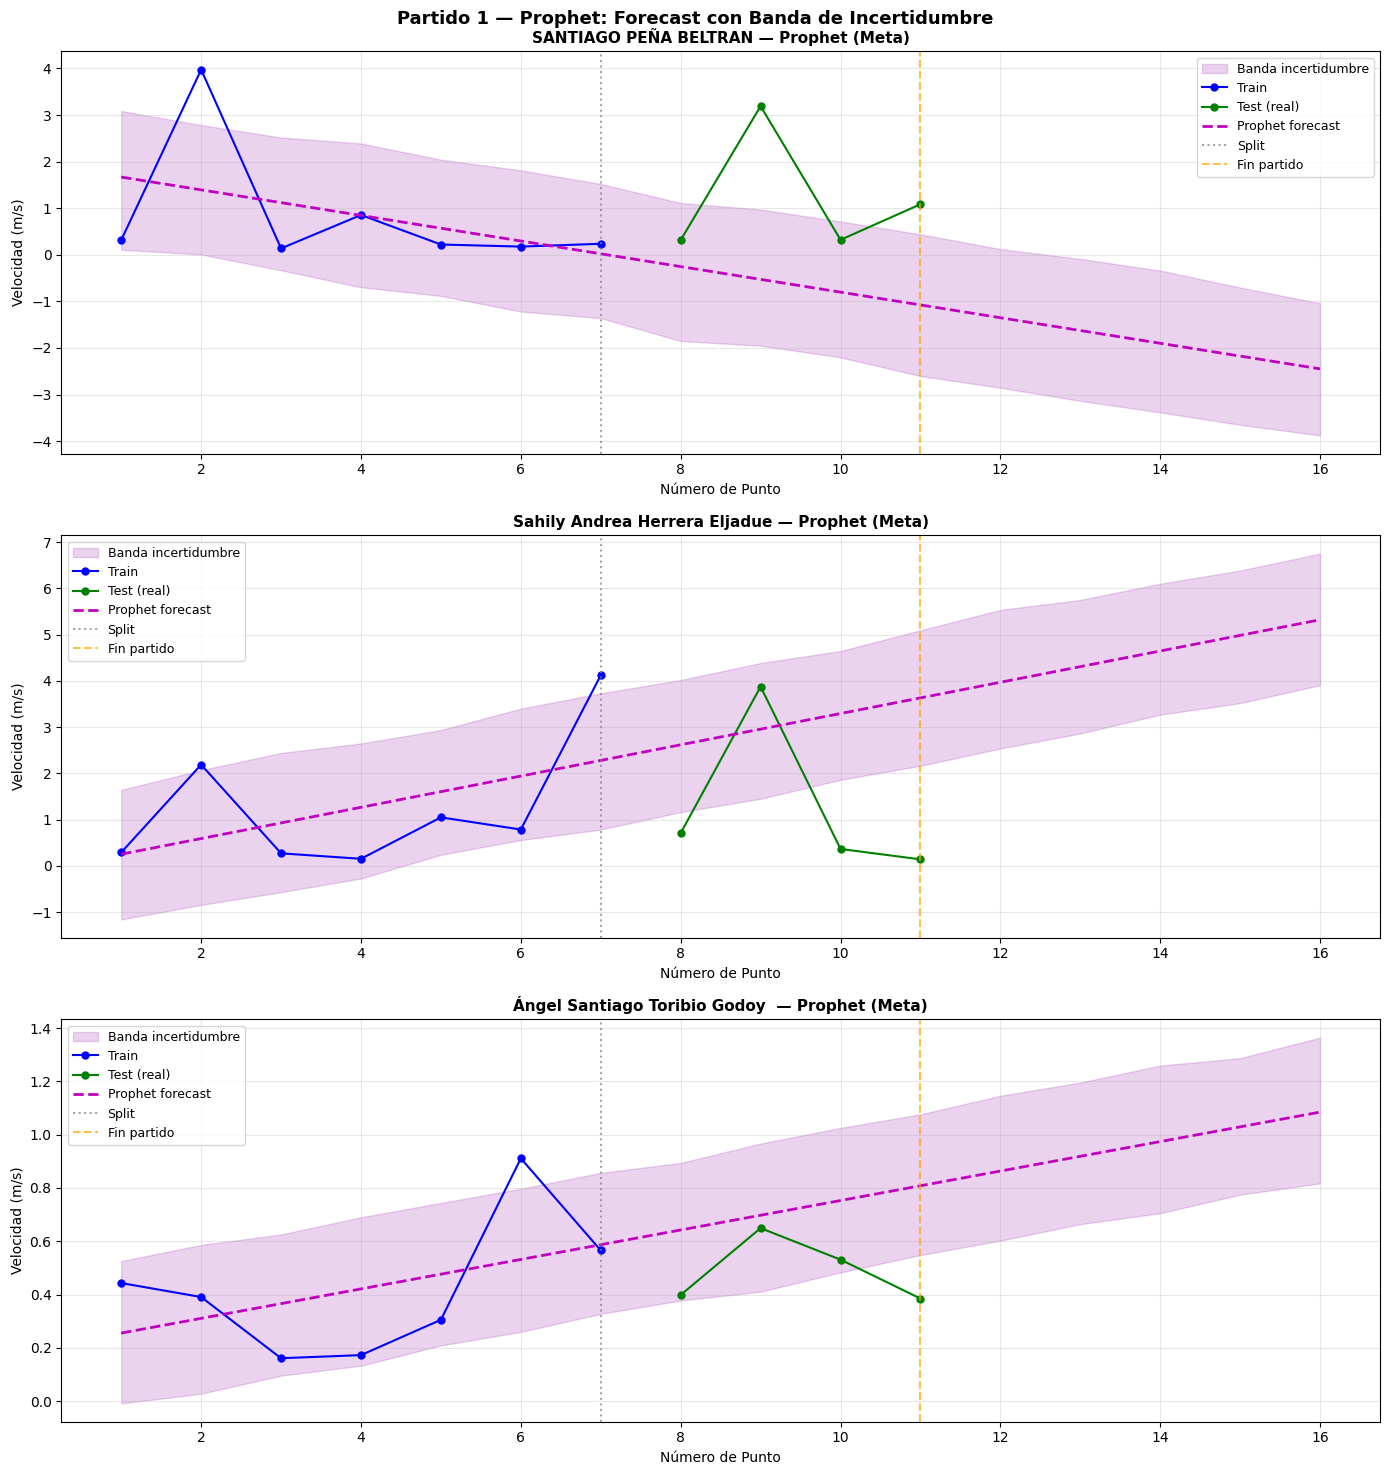

In [19]:
from datetime import datetime, timedelta

if not PROPHET_AVAILABLE:
    print('⚠️  Prophet no está instalado.')
    print('   Ejecuta en tu terminal: pip install prophet')
else:
    print(f'🔮 Prophet de Meta — Partido {PARTIDO_NUM}\n')
    FUTURE_POINTS = 5
    fecha_inicio  = datetime(2024, 1, 1)

    n_eval = len(jugadores_eval)
    fig, axes = plt.subplots(n_eval, 1, figsize=(14, 5 * n_eval))
    if n_eval == 1:
        axes = [axes]

    for ax, jugador in zip(axes, jugadores_eval):
        datos      = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num')
        puntos     = datos['punto_num'].values
        serie      = datos['desplazamiento_total'].values
        split      = indices_split[jugador]
        train, test = serie[:split], serie[split:]
        max_punto   = int(puntos.max())

        fechas_all = [fecha_inicio + timedelta(days=int(p)) for p in puntos]
        df_prophet = pd.DataFrame({'ds': fechas_all, 'y': serie})
        df_train_p = df_prophet.iloc[:split]

        try:
            modelo_p = Prophet(
                yearly_seasonality=False,
                weekly_seasonality=False,
                daily_seasonality=False,
                changepoint_prior_scale=0.3
            )
            modelo_p.fit(df_train_p)

            rango_futuro  = range(1, max_punto + FUTURE_POINTS + 1)
            fechas_futuro = [fecha_inicio + timedelta(days=p) for p in rango_futuro]
            forecast      = modelo_p.predict(pd.DataFrame({'ds': fechas_futuro}))

            fechas_test   = [fecha_inicio + timedelta(days=int(p)) for p in puntos[split:]]
            pred_test_p   = forecast[forecast['ds'].isin(fechas_test)]['yhat'].values
            if len(pred_test_p) == len(test):
                resultados_globales[jugador].append(
                    evaluar_modelo(test, pred_test_p, 'Prophet (Meta)')
                )

            x_range = list(rango_futuro)
            ax.fill_between(x_range,
                            forecast['yhat_lower'].values,
                            forecast['yhat_upper'].values,
                            alpha=0.2, color='#9C27B0', label='Banda incertidumbre')
            ax.plot(puntos[:split], train,  'b-o', label='Train',        ms=5)
            ax.plot(puntos[split:], test,   'g-o', label='Test (real)',  ms=5)
            ax.plot(x_range, forecast['yhat'].values, 'm--', label='Prophet forecast', lw=2)
            ax.axvline(x=puntos[split - 1], color='gray',   linestyle=':', alpha=0.7, label='Split')
            ax.axvline(x=max_punto,          color='orange', linestyle='--', alpha=0.7, label='Fin partido')

        except Exception as exc:
            print(f'  ⚠️  Error Prophet para {jugador}: {exc}')

        ax.set_title(f'{jugador} — Prophet (Meta)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Número de Punto')
        ax.set_ylabel('Desplazamiento (m)')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Partido {PARTIDO_NUM} — Prophet: Forecast con Banda de Incertidumbre',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 📋 SECCIÓN 10 — Tabla Comparativa de Modelos
*(Grupo 11: Evaluación de Modelos de Forecasting)*

In [20]:
print('=' * 70)
print(f'TABLA COMPARATIVA DE MODELOS — Partido {PARTIDO_NUM}  (MAE y RMSE en metros)')
print('=' * 70)

tabla_global = []

for jugador, lista_metricas in resultados_globales.items():
    if not lista_metricas:
        continue
    df_m = pd.DataFrame(lista_metricas).set_index('modelo')
    print(f'\n👤 {jugador}')
    print(df_m.to_string())
    print(f'   → Mejor MAE : {df_m["MAE"].idxmin()}')
    print(f'   → Mejor RMSE: {df_m["RMSE"].idxmin()}')
    for _, row in df_m.reset_index().iterrows():
        tabla_global.append({'jugador': jugador, **row.to_dict()})

print()
print('=' * 70)
print('RESUMEN GLOBAL — promedio de MAE y RMSE por modelo (todos los jugadores)')
print('=' * 70)
df_global = pd.DataFrame(tabla_global)
if not df_global.empty:
    # Agrupar variantes de ARIMA (ej. ARIMA(1,0,0), ARIMA(1,1,0)) bajo "ARIMA"
    # para una comparación justa entre familias de modelos
    df_global['modelo_familia'] = df_global['modelo'].str.replace(
        r'ARIMA\(.*?\)', 'ARIMA', regex=True
    )
    resumen = df_global.groupby('modelo_familia')[['MAE', 'RMSE']].mean().round(4).sort_values('RMSE')
    print(resumen.to_string())
    print(f'\n→ Modelo más preciso en promedio (menor RMSE): {resumen["RMSE"].idxmin()}')
    print('  (ARIMA agrupa todos los órdenes detectados automáticamente por jugador)')

print()
print('💡 MAE y RMSE en metros — menor valor = mejor predicción del desplazamiento futuro')

TABLA COMPARATIVA DE MODELOS — Partido 1  (MAE y RMSE en m/s)

👤 SANTIAGO PEÑA BELTRAN
                                  MAE    RMSE
modelo                                       
Naive (último valor conocido)  0.9920  1.5383
Exp. Smoothing (Holt)          1.9055  2.2517
ARIMA(1, 0, 0)                 0.9610  1.2656
Prophet (Meta)                 1.8932  2.2410
   → Mejor MAE : ARIMA(1, 0, 0)
   → Mejor RMSE: ARIMA(1, 0, 0)

👤 Sahily Andrea Herrera Eljadue
                                  MAE    RMSE
modelo                                       
Naive (último valor conocido)  2.8478  3.2261
Exp. Smoothing (Holt)          2.3114  2.5119
ARIMA(1, 0, 0)                 1.1663  1.3476
Prophet (Meta)                 2.3112  2.5115
   → Mejor MAE : ARIMA(1, 0, 0)
   → Mejor RMSE: ARIMA(1, 0, 0)

👤 Ángel Santiago Toribio Godoy 
                                  MAE    RMSE
modelo                                       
Naive (último valor conocido)  0.1165  0.1311
Exp. Smoothing (Holt)        

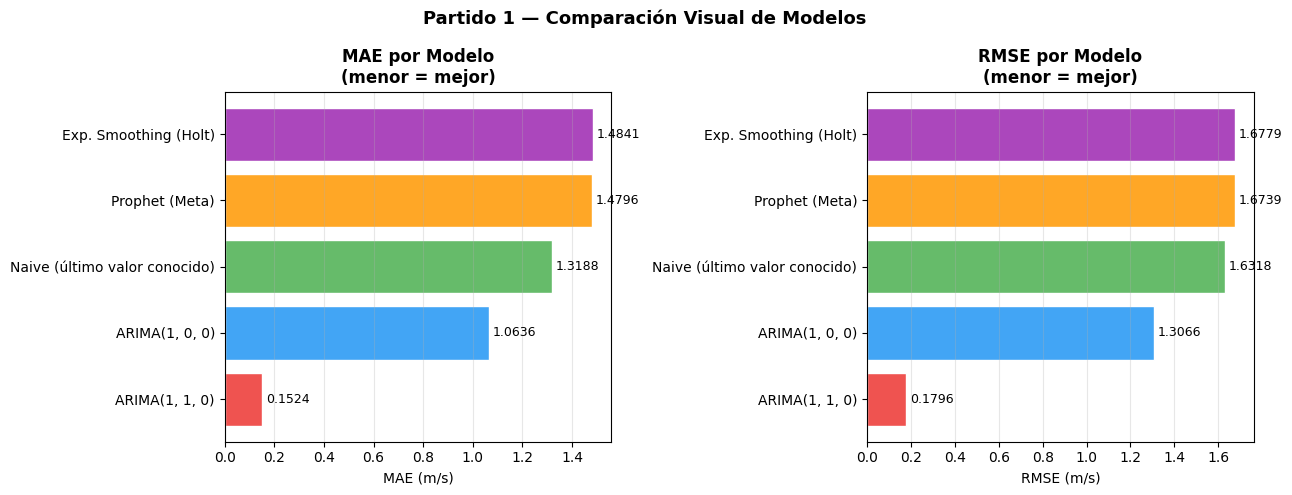

In [21]:
# ---- Bar chart visual de MAE y RMSE por modelo -------------------------
if 'resumen' in dir() and not df_global.empty and len(resumen) >= 2:
    fig_bar, ax_bar = plt.subplots(1, 2, figsize=(13, max(3, len(resumen) * 0.8 + 1)))
    _mods = resumen.index.tolist()
    _pal  = ['#EF5350', '#42A5F5', '#66BB6A', '#FFA726', '#AB47BC'][:len(_mods)]

    ax_bar[0].barh(_mods, resumen['MAE'].values,  color=_pal, edgecolor='white')
    ax_bar[0].set_title('MAE por Modelo\n(menor = mejor)', fontweight='bold')
    ax_bar[0].set_xlabel('MAE (m)')
    for _i, _v in enumerate(resumen['MAE'].values):
        ax_bar[0].text(_v + resumen['MAE'].max() * 0.01, _i, f'{_v:.4f}', va='center', fontsize=9)
    ax_bar[0].grid(True, alpha=0.3, axis='x')

    ax_bar[1].barh(_mods, resumen['RMSE'].values, color=_pal, edgecolor='white')
    ax_bar[1].set_title('RMSE por Modelo\n(menor = mejor)', fontweight='bold')
    ax_bar[1].set_xlabel('RMSE (m)')
    for _i, _v in enumerate(resumen['RMSE'].values):
        ax_bar[1].text(_v + resumen['RMSE'].max() * 0.01, _i, f'{_v:.4f}', va='center', fontsize=9)
    ax_bar[1].grid(True, alpha=0.3, axis='x')

    fig_bar.suptitle(f'Partido {PARTIDO_NUM} \u2014 Comparaci\u00f3n Visual de Modelos',
                     fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('\u26a0\ufe0f  Se necesitan al menos 2 modelos evaluados para mostrar el gr\u00e1fico.')


## 🏆 SECCIÓN 11 — Comparación entre Jugadores, Equipos y Partido

⚡ Estabilidad de velocidad — Partido 1

Estabilidad por equipo y jugador:
                                       Media     Std  Varianza  Puntos
team   player_name                                                    
bottom SANTIAGO PEÑA BELTRAN          1.0498  1.3828    1.9121      10
       Ángel Santiago Toribio Godoy   0.4467  0.2154    0.0464      11
top    SANTIAGO PEÑA BELTRAN          0.3211     NaN       NaN       1
       Sahily Andrea Herrera Eljadue  1.2691  1.4711    2.1643      11

Varianza promedio de velocidad por equipo:
  bottom: 0.9789  ← más estable
  top: 2.0424  


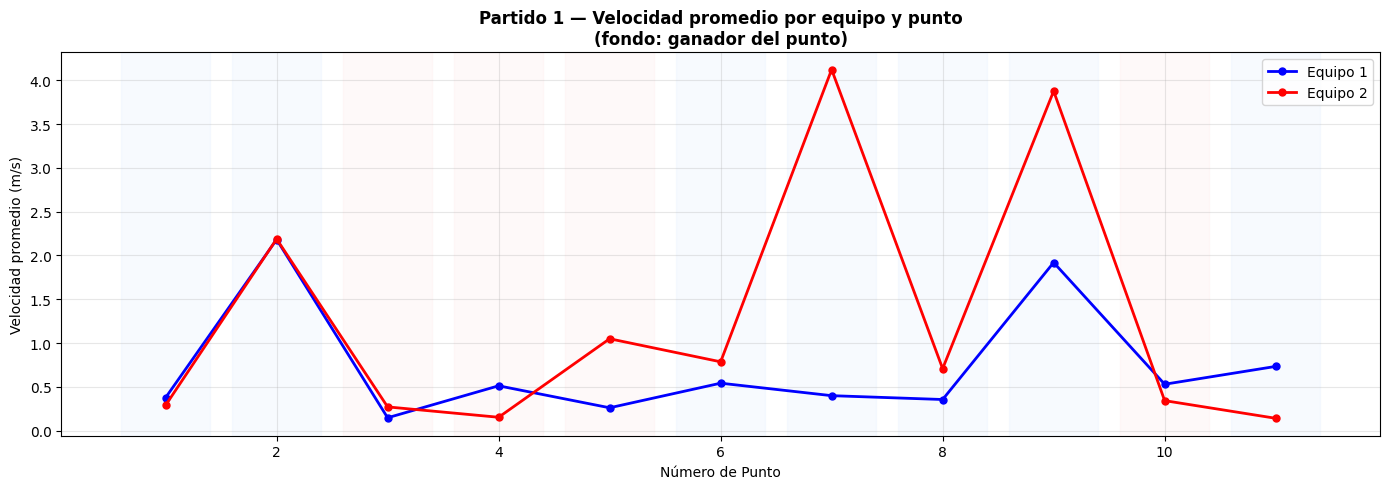

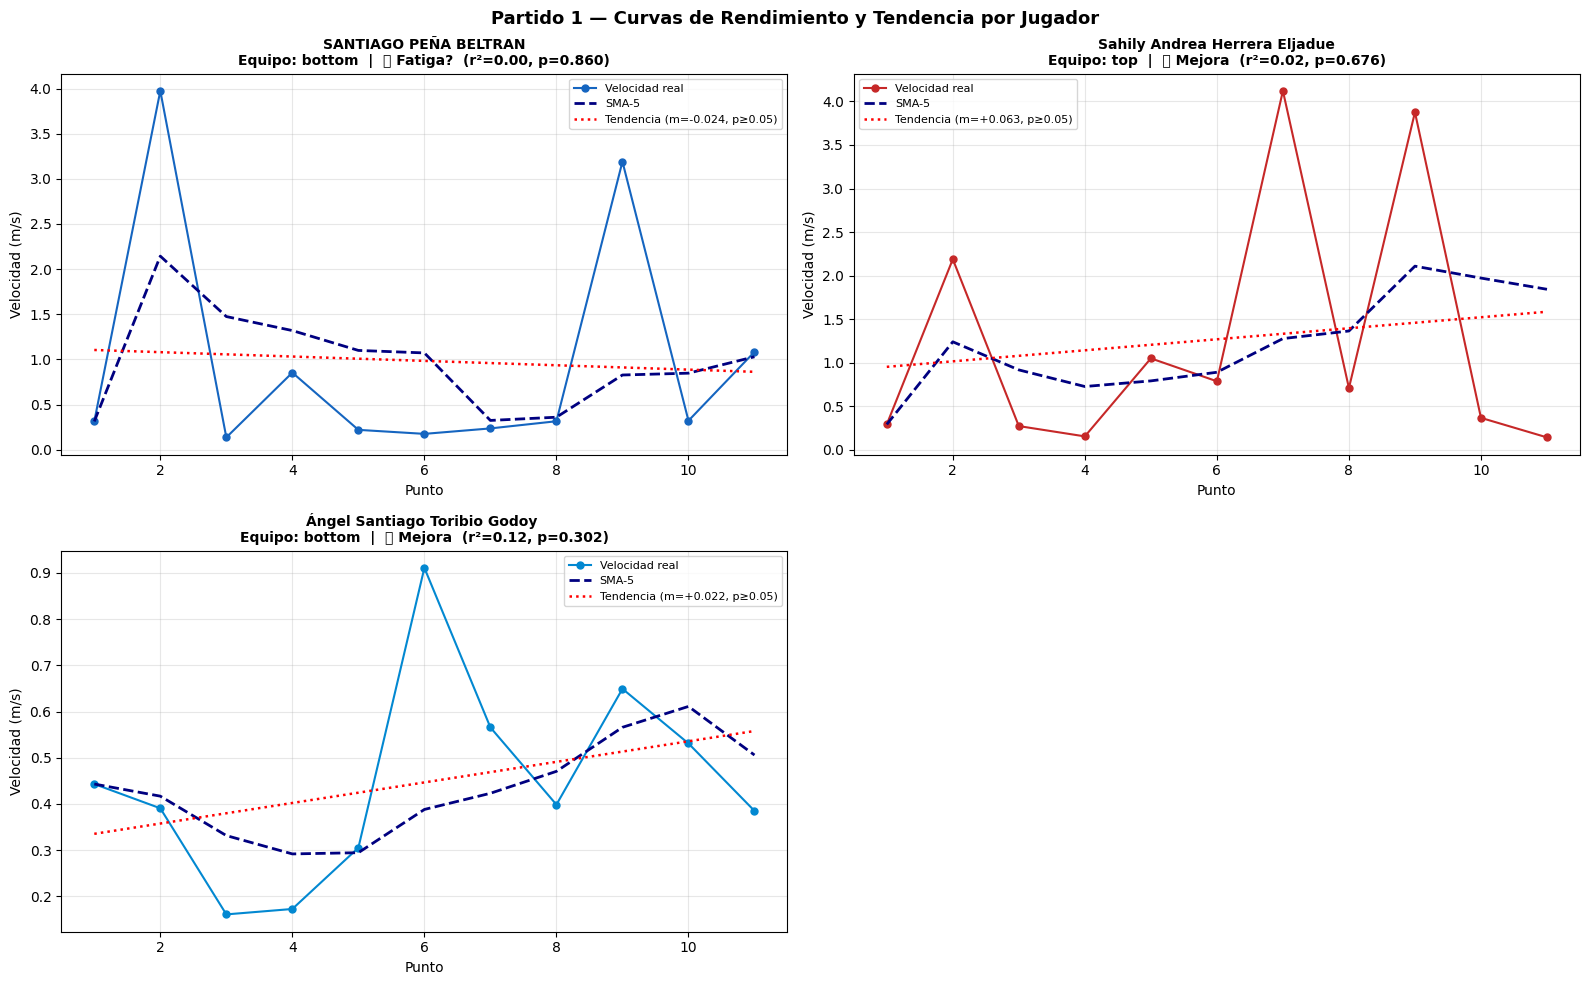


💡 Pendiente de tendencia lineal:
  m < -0.01 → velocidad cae por punto (fatiga progresiva)
  m ≈  0    → rendimiento estable
  m >  0.01 → aceleración del ritmo


In [22]:
print(f'⚡ Estabilidad de desplazamiento — Partido {PARTIDO_NUM}\n')

# ---- Estabilidad por equipo ---------------------------------
stab = (
    serie_temporal
    .groupby(['team', 'player_name'])['desplazamiento_total']
    .agg(Media='mean', Std='std', Varianza='var', Puntos='count')
    .round(4)
)
print('Estabilidad por equipo y jugador:')
print(stab.to_string())

team_var = serie_temporal.groupby('team')['desplazamiento_total'].var().round(4)
print('\nVarianza del desplazamiento total por equipo:')
for team, var in team_var.items():
    tag = '← más estable' if var == team_var.min() else ''
    print(f'  {team}: {var}  {tag}')

# ---- Desplazamiento: ¿el equipo ganador es más activo? --
if ganador_por_punto and traza_partido is not None and not traza_partido.empty:
    equipo1_pos = traza_partido.iloc[0]['EQUIPO_1_POSICION'].lower()
    serie_temporal['ganador_punto'] = serie_temporal['punto_num'].map(
        lambda p: ganador_por_punto.get(p, None)
    )
    serie_temporal['es_equipo1'] = serie_temporal['team'].str.lower() == equipo1_pos
    serie_temporal['equipo_label'] = serie_temporal['es_equipo1'].map(
        {True: 'EQUIPO_1', False: 'EQUIPO_2'}
    )
    vel_por_equipo_punto = (
        serie_temporal
        .groupby(['punto_num', 'equipo_label'])['desplazamiento_total']
        .mean()
        .unstack()
    )
    fig, ax = plt.subplots(figsize=(14, 5))
    if 'EQUIPO_1' in vel_por_equipo_punto.columns:
        ax.plot(vel_por_equipo_punto.index, vel_por_equipo_punto['EQUIPO_1'],
                'b-o', label='Equipo 1', ms=5, lw=2)
    if 'EQUIPO_2' in vel_por_equipo_punto.columns:
        ax.plot(vel_por_equipo_punto.index, vel_por_equipo_punto['EQUIPO_2'],
                'r-o', label='Equipo 2', ms=5, lw=2)
    # Fondo por ganador
    for punto, ganador in ganador_por_punto.items():
        bg = '#dbeafe' if ganador == 'EQUIPO_1' else '#fee2e2'
        ax.axvspan(punto - 0.4, punto + 0.4, alpha=0.2, color=bg)
    ax.set_title(f'Partido {PARTIDO_NUM} — Desplazamiento total promedio por equipo y punto\n(fondo: ganador del punto)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Número de Punto')
    ax.set_ylabel('Desplazamiento total (m)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---- Plot 4 jugadores con tendencia lineal ------------------
n_plot = min(4, len(jugadores))
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_flat = axes.flatten()

for i, jugador in enumerate(jugadores[:n_plot]):
    ax    = axes_flat[i]
    datos = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num')
    x_pts = datos['punto_num'].values
    y_spd = datos['desplazamiento_total'].values
    color = color_map.get(jugador, 'steelblue')

    ax.plot(x_pts, y_spd, 'o-', color=color, label='Desplazamiento real', ms=5)
    ax.plot(x_pts, datos['SMA5'].values, '--', color='navy', label='SMA-5', lw=2)

    if len(x_pts) >= 2:
        _sl_t, _int_t, _r_t, _p_t, _ = stats.linregress(x_pts, y_spd)
        pendiente = _sl_t
        _sig_tag = '\u2713 p<0.05' if _p_t < 0.05 else 'p\u22650.05'
        ax.plot(x_pts, _sl_t * x_pts + _int_t, 'r:', lw=1.8,
                label=f'Tendencia (m={pendiente:+.3f}, {_sig_tag})')
        if pendiente < -0.5 and _p_t < 0.05:
            signo = '\U0001f4c9 Fatiga sig.'
        elif pendiente < -0.5:
            signo = '\U0001f4c9 Fatiga?'
        elif pendiente > 0.5:
            signo = '\U0001f4c8 Mejora'
        else:
            signo = '\u27a1 Estable'
        titulo = (f'{jugador}\nEquipo: {equipos.get(jugador, "?")}  |  '
                  f'{signo}  (r\u00b2={_r_t**2:.2f}, p={_p_t:.3f})')
    else:
        titulo = f'{jugador}'

    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('Punto')
    ax.set_ylabel('Desplazamiento (m)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for i in range(n_plot, 4):
    axes_flat[i].set_visible(False)

plt.suptitle(f'Partido {PARTIDO_NUM} — Curvas de Desplazamiento y Tendencia de Fatiga por Jugador',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Pendiente de tendencia lineal:')
print('  m < -0.5  → desplazamiento cae por punto (fatiga progresiva)')
print('  m ≈  0    → rendimiento estable')
print('  m >  0.5  → aceleración del ritmo')

## ⚔️ SECCIÓN 11B — Correlación Fatiga → Resultado del Punto

**¿El equipo más fatigado en un punto dado pierde ese punto con mayor frecuencia?**

Metodología:
- Para cada punto P se calcula la **velocidad promedio histórica** (puntos 1..P−1) de cada equipo.
- El equipo con menor desplazamiento histórico se considera *más fatigado* en ese punto.
- Se cuenta cuántas veces ese equipo gana vs pierde.
- Test binomial: H₀ = la fatiga no predice el resultado (probabilidad 0.5).

Análisis fatiga → resultado del punto — Partido 1
  Puntos analizados              : 9
  Equipo más fatigado PIERDE     : 2/9  (22.2%)
  Equipo más fatigado GANA       : 7/9  (77.8%)
  Test binomial (H0: azar 50/50)  : p = 0.1797
  → No significativo con estos datos


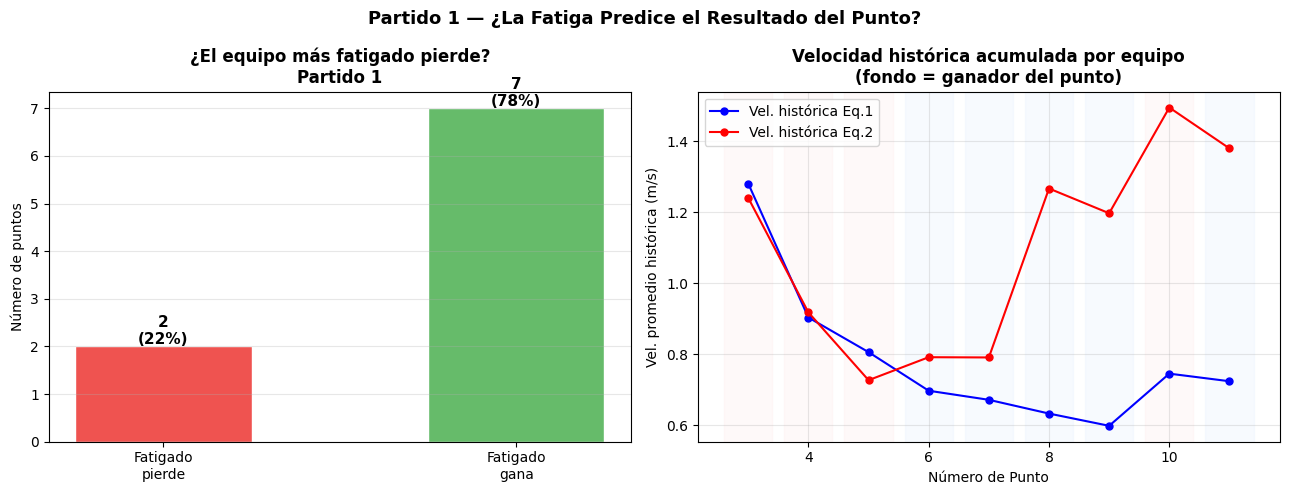


 punto equipo_mas_fatigado  ganador  fatigado_gano
     3            EQUIPO_2 EQUIPO_2           True
     4            EQUIPO_1 EQUIPO_2          False
     5            EQUIPO_2 EQUIPO_2           True
     6            EQUIPO_1 EQUIPO_1           True
     7            EQUIPO_1 EQUIPO_1           True
     8            EQUIPO_1 EQUIPO_1           True
     9            EQUIPO_1 EQUIPO_1           True
    10            EQUIPO_1 EQUIPO_2          False
    11            EQUIPO_1 EQUIPO_1           True


In [23]:
if not ganador_por_punto or traza_partido is None or traza_partido.empty:
    print('\u26a0\ufe0f  Sin datos de ganador por punto. Saltando an\u00e1lisis fatiga \u2192 resultado.')
else:
    _eq1_pos = traza_partido.iloc[0]['EQUIPO_1_POSICION'].lower()
    _serie_eq = serie_temporal.copy()
    _serie_eq['equipo_label'] = _serie_eq['team'].str.lower().apply(
        lambda t: 'EQUIPO_1' if t == _eq1_pos else 'EQUIPO_2'
    )

    _vel_eq_pt = (
        _serie_eq.groupby(['punto_num', 'equipo_label'])['desplazamiento_total']
        .mean().unstack()
    )

    _res_fatiga = []
    for _pto in sorted(ganador_por_punto.keys()):
        if _pto not in _vel_eq_pt.index:
            continue
        _prev = [p for p in _vel_eq_pt.index if p < _pto]
        if len(_prev) < 2:
            continue
        _hist = _vel_eq_pt.loc[_prev]
        _v1 = _hist['EQUIPO_1'].mean() if 'EQUIPO_1' in _hist.columns else np.nan
        _v2 = _hist['EQUIPO_2'].mean() if 'EQUIPO_2' in _hist.columns else np.nan
        if np.isnan(_v1) or np.isnan(_v2):
            continue
        _gan = ganador_por_punto[_pto]
        _mas_fatigado = 'EQUIPO_1' if _v1 < _v2 else 'EQUIPO_2'
        _res_fatiga.append({
            'punto': _pto,
            'vel_eq1_hist': round(_v1, 4),
            'vel_eq2_hist': round(_v2, 4),
            'equipo_mas_fatigado': _mas_fatigado,
            'ganador': _gan,
            'fatigado_gano': _gan == _mas_fatigado
        })

    df_fatiga_res = pd.DataFrame(_res_fatiga)

    if df_fatiga_res.empty:
        print('\u26a0\ufe0f  Insuficientes puntos para el an\u00e1lisis de correlaci\u00f3n.')
    else:
        _tot  = len(df_fatiga_res)
        _gano = int(df_fatiga_res['fatigado_gano'].sum())
        _perd = _tot - _gano
        print(f'An\u00e1lisis fatiga \u2192 resultado del punto \u2014 Partido {PARTIDO_NUM}')
        print(f'  Puntos analizados              : {_tot}')
        print(f'  Equipo m\u00e1s fatigado PIERDE     : {_perd}/{_tot}  ({_perd/_tot*100:.1f}%)')
        print(f'  Equipo m\u00e1s fatigado GANA       : {_gano}/{_tot}  ({_gano/_tot*100:.1f}%)')

        from scipy.stats import binomtest
        _bt = binomtest(_perd, _tot, 0.5)
        print(f'  Test binomial (H0: azar 50/50)  : p = {_bt.pvalue:.4f}')
        if _bt.pvalue < 0.05:
            print('  \u2192 SIGNIFICATIVO: el equipo m\u00e1s fatigado pierde m\u00e1s de lo esperado por azar')
        else:
            print('  \u2192 No significativo con estos datos')

        fig_11b, ax_11b = plt.subplots(1, 2, figsize=(13, 5))

        ax_11b[0].bar(['Fatigado\npierde', 'Fatigado\ngana'],
                      [_perd, _gano],
                      color=['#ef5350', '#66bb6a'], edgecolor='white', width=0.5)
        ax_11b[0].set_title(f'\u00bfEl equipo m\u00e1s fatigado pierde?\nPartido {PARTIDO_NUM}',
                            fontweight='bold')
        ax_11b[0].set_ylabel('N\u00famero de puntos')
        for _j, _v in enumerate([_perd, _gano]):
            ax_11b[0].text(_j, _v + 0.05, f'{_v}\n({_v/_tot*100:.0f}%)',
                           ha='center', fontsize=11, fontweight='bold')
        ax_11b[0].grid(True, alpha=0.3, axis='y')

        ax_11b[1].plot(df_fatiga_res['punto'], df_fatiga_res['vel_eq1_hist'],
                       'b-o', label='Vel. hist\u00f3rica Eq.1', ms=5)
        ax_11b[1].plot(df_fatiga_res['punto'], df_fatiga_res['vel_eq2_hist'],
                       'r-o', label='Vel. hist\u00f3rica Eq.2', ms=5)
        for _, _row in df_fatiga_res.iterrows():
            _bg = '#dbeafe' if _row['ganador'] == 'EQUIPO_1' else '#fee2e2'
            ax_11b[1].axvspan(_row['punto'] - 0.4, _row['punto'] + 0.4, alpha=0.2, color=_bg)
        ax_11b[1].set_title('Velocidad hist\u00f3rica acumulada por equipo\n(fondo = ganador del punto)',
                            fontweight='bold')
        ax_11b[1].set_xlabel('N\u00famero de Punto')
        ax_11b[1].set_ylabel('Vel. promedio hist\u00f3rica (m)')
        ax_11b[1].legend()
        ax_11b[1].grid(True, alpha=0.3)

        fig_11b.suptitle(f'Partido {PARTIDO_NUM} \u2014 \u00bfLa Fatiga Predice el Resultado del Punto?',
                         fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print()
        print(df_fatiga_res[['punto','equipo_mas_fatigado','ganador','fatigado_gano']].to_string(index=False))


📊 Análisis Multi-Partido — Pendiente de Fatiga por Jugador

 partido                           jugador  pendiente  p_valor    r2  n_puntos sig
      38         Juan Esteban Bustos Marín   -1.53349   0.0638 0.409         9    
      28                     Juliana Gomez   -1.24034   0.1234 0.349         8    
       7         Juan Esteban Bustos Marín   -1.01505   0.2628 0.175         9    
      19                Nicolas Navarro D.   -0.55223   0.1062 0.293        10    
      14      Juan sebastian melo gonzalez   -0.53033   0.0418 0.996         3   *
      34         Alejandra Salazar Galeano   -0.46524   0.2400 0.578         4    
      34                     Juliana Gomez   -0.42658   0.5084 0.116         6    
      14                     Juliana Gomez   -0.36002   0.4646 0.555         3    
       3              Laura Natalia Garcia   -0.14185   0.0334 0.499         9   *
      14                Juan David Quitian   -0.13497   0.6000 0.346         3    
      28 Gabriel Alejandro 

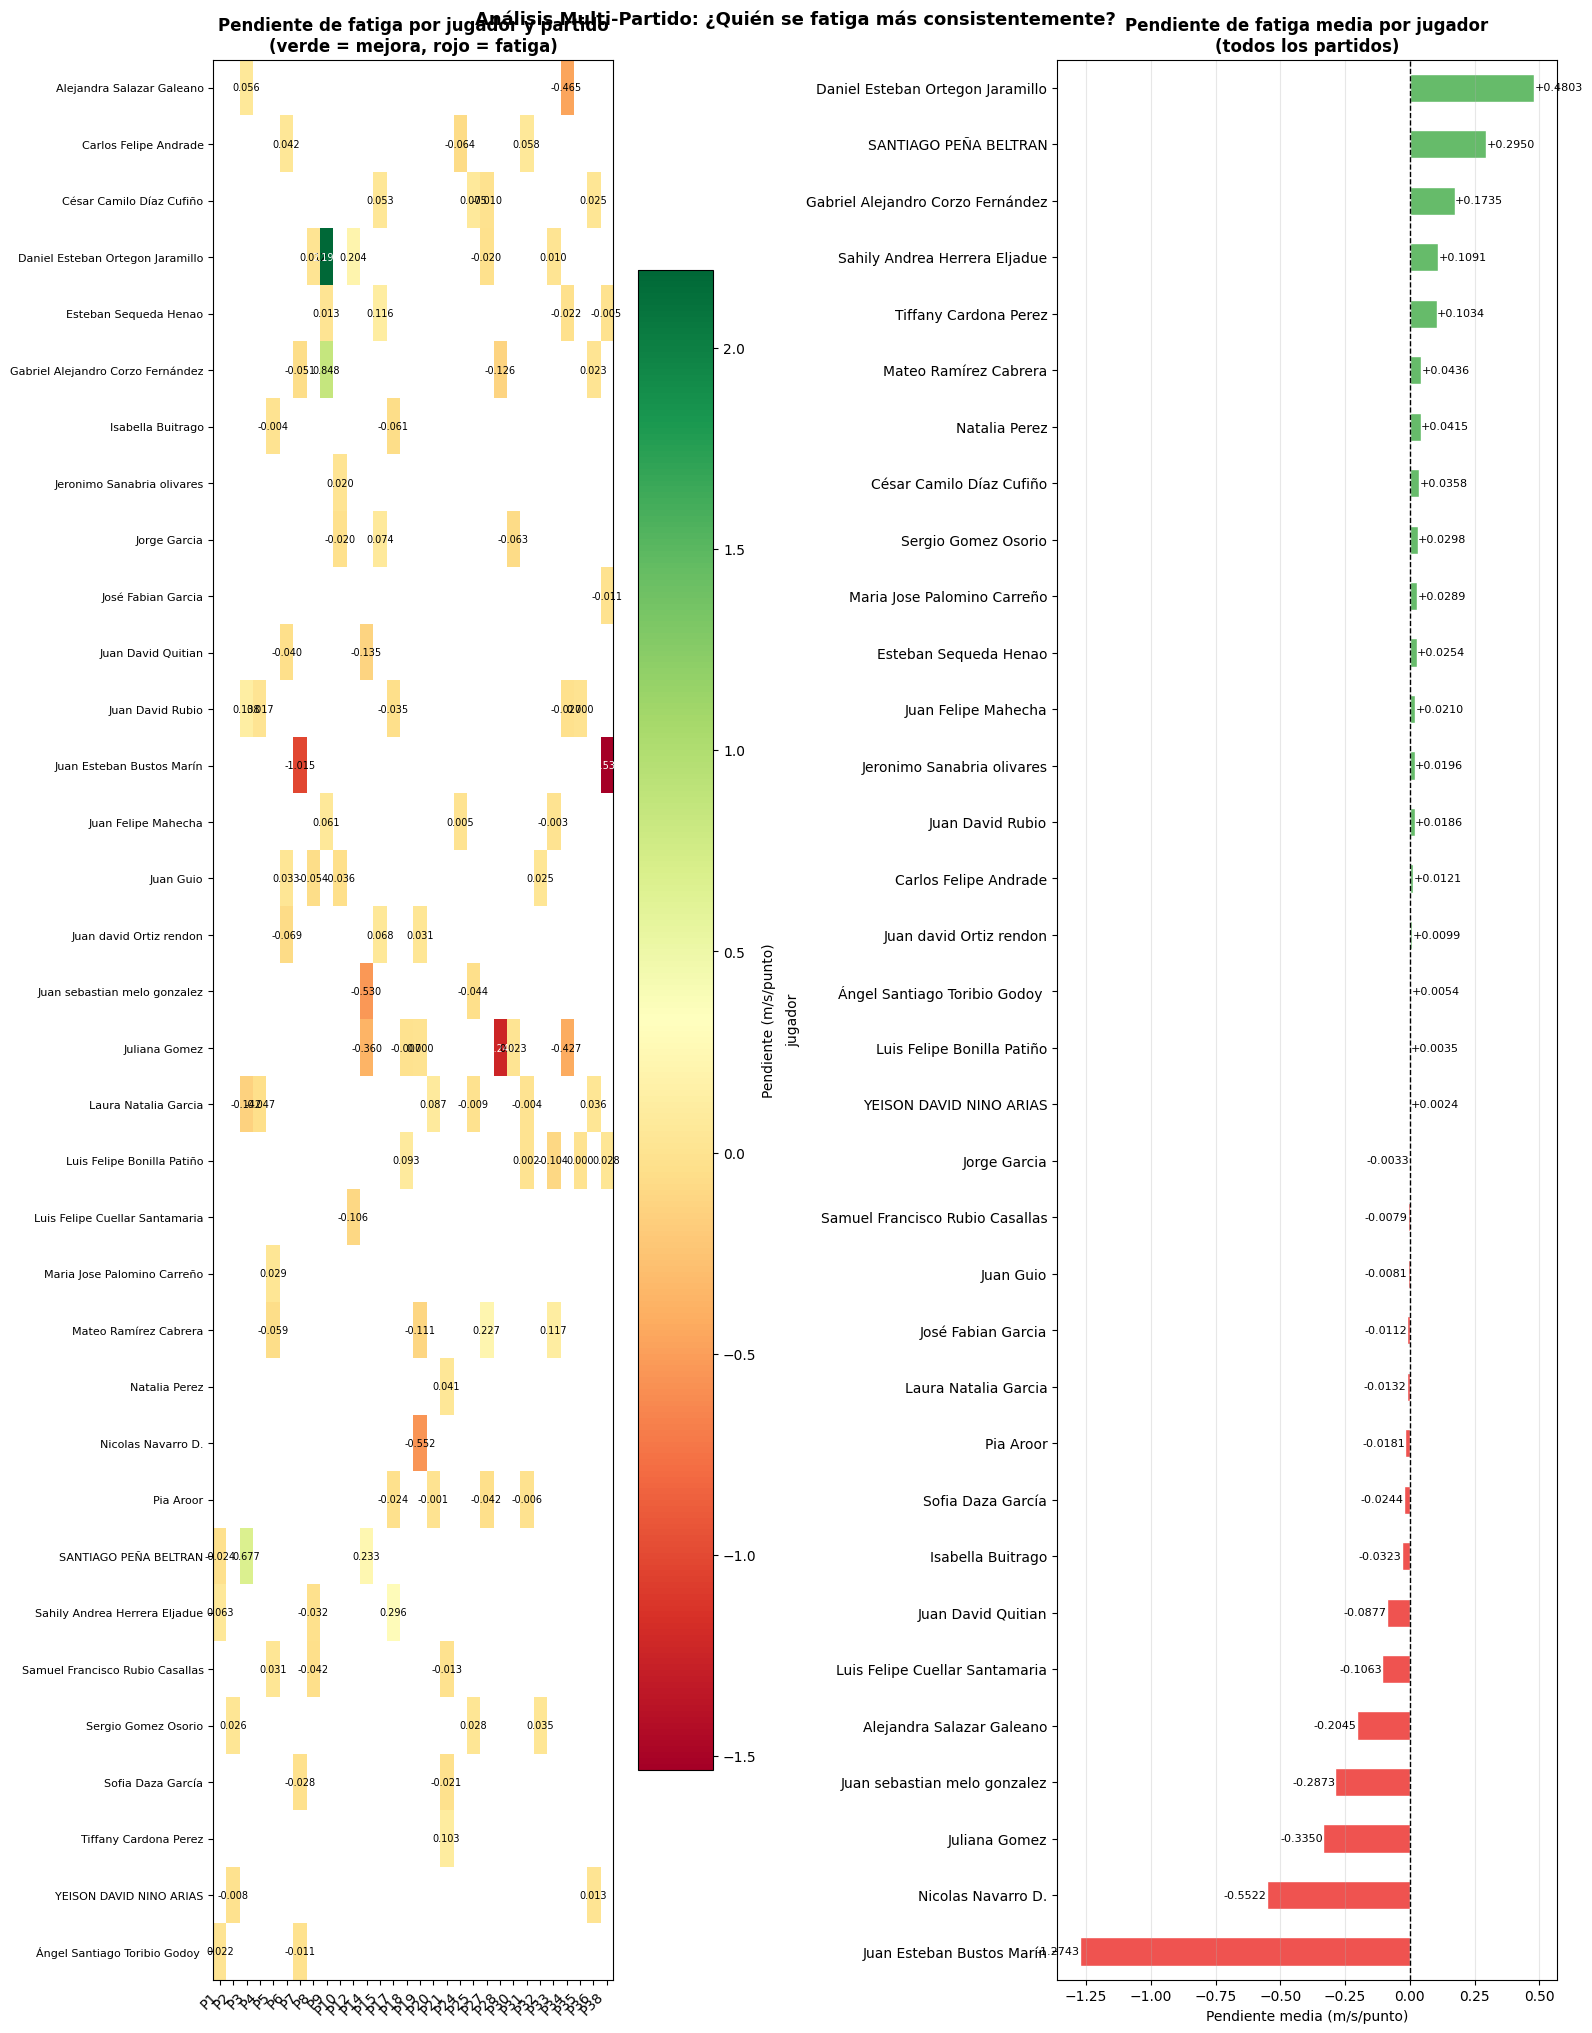


Jugadores con fatiga estadísticamente significativa (p<0.05):
  Juan Guio: 1/4 partidos sig.  (pendiente media: -0.0081 m/s/punto)
  Juan sebastian melo gonzalez: 1/2 partidos sig.  (pendiente media: -0.2873 m/s/punto)
  Laura Natalia Garcia: 1/6 partidos sig.  (pendiente media: -0.0132 m/s/punto)
  Maria Jose Palomino Carreño: 1/1 partidos sig.  (pendiente media: +0.0289 m/s/punto)
  Sahily Andrea Herrera Eljadue: 1/3 partidos sig.  (pendiente media: +0.1091 m/s/punto)


In [24]:
print('\U0001f4ca An\u00e1lisis Multi-Partido \u2014 Pendiente de Fatiga por Jugador\n')

_multi_pends = []
for _pid2 in sorted(df_raw['partido'].unique()):
    _dfp2 = df_raw[
        (df_raw['partido'] == _pid2) &
        (~df_raw['player_name'].str.match(r'^Player_\d+$', na=False)) &
        (df_raw['player_speed_mps'] <= 8.0)
    ].copy()
    _team_c2 = (
        _dfp2.groupby('player_name')['team']
        .agg(lambda x: x.mode()[0])
        .to_dict()
    )
    _dfp2['team'] = _dfp2['player_name'].map(_team_c2)
    _stp2 = (
        _dfp2.groupby(['punto', 'player_name'])
        .agg(desplazamiento_total=('player_displacement', 'sum'))
        .reset_index()
        .sort_values(['player_name', 'punto'])
    )
    for _jug2 in _stp2['player_name'].unique():
        _d2 = _stp2[_stp2['player_name'] == _jug2].sort_values('punto')
        _x2, _y2 = _d2['punto'].values, _d2['desplazamiento_total'].values
        if len(_x2) >= 3:
            _sl2, _, _r2, _p2, _ = stats.linregress(_x2, _y2)
            _multi_pends.append({
                'partido': _pid2, 'jugador': _jug2,
                'pendiente': round(_sl2, 5), 'p_valor': round(_p2, 4),
                'r2': round(_r2**2, 3), 'n_puntos': len(_x2),
                'sig': '*' if _p2 < 0.05 else ''
            })

df_multi = pd.DataFrame(_multi_pends)
print(df_multi.sort_values('pendiente').to_string(index=False))

# ---- Heatmap + ranking horizontal -----------------------------------
_pivot = df_multi.pivot_table(index='jugador', columns='partido',
                               values='pendiente', aggfunc='mean')

fig_mp, ax_mp = plt.subplots(1, 2, figsize=(16, max(4, len(_pivot) * 0.55 + 2)))

_vals = _pivot.values.astype(float)
_vmin = float(np.nanmin(_vals))
_vmax = float(np.nanmax(_vals))
_im   = ax_mp[0].imshow(_vals, cmap='RdYlGn', aspect='auto', vmin=_vmin, vmax=_vmax)
ax_mp[0].set_xticks(range(len(_pivot.columns)))
ax_mp[0].set_xticklabels([f'P{c}' for c in _pivot.columns], rotation=45, ha='right')
ax_mp[0].set_yticks(range(len(_pivot.index)))
ax_mp[0].set_yticklabels(_pivot.index, fontsize=8)
ax_mp[0].set_title('Pendiente de fatiga por jugador y partido\n(verde = mejora, rojo = fatiga)',
                    fontweight='bold')
for _ii in range(len(_pivot.index)):
    for _jj in range(len(_pivot.columns)):
        _vv = _vals[_ii, _jj]
        if not np.isnan(_vv):
            ax_mp[0].text(_jj, _ii, f'{_vv:.3f}', ha='center', va='center', fontsize=7,
                          color='white' if abs(_vv) > (_vmax - _vmin) * 0.3 else 'black')
plt.colorbar(_im, ax=ax_mp[0], label='Pendiente (m/punto)')

_media_jug = df_multi.groupby('jugador')['pendiente'].mean().sort_values()
_c_mp = ['#ef5350' if v < 0 else '#66bb6a' for v in _media_jug.values]
_media_jug.plot(kind='barh', ax=ax_mp[1], color=_c_mp, edgecolor='white')
ax_mp[1].axvline(0, color='black', lw=1, ls='--')
ax_mp[1].set_title('Pendiente de fatiga media por jugador\n(todos los partidos)', fontweight='bold')
ax_mp[1].set_xlabel('Pendiente media (m/punto)')
for _ii2, (_nom, _vv2) in enumerate(_media_jug.items()):
    _off = 0.001 if _vv2 >= 0 else -0.001
    ax_mp[1].text(_vv2 + _off, _ii2, f'{_vv2:+.4f}', va='center',
                  ha='left' if _vv2 >= 0 else 'right', fontsize=8)
ax_mp[1].grid(True, alpha=0.3, axis='x')

fig_mp.suptitle('An\u00e1lisis Multi-Partido: \u00bfQui\u00e9n se fatiga m\u00e1s consistentemente?',
                fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

_sig_c = df_multi[df_multi['sig'] == '*'].groupby('jugador').size()
print('\nJugadores con fatiga estad\u00edsticamente significativa (p<0.05):')
if len(_sig_c) > 0:
    for _jj_s, _ns in _sig_c.sort_values(ascending=False).items():
        _tot_j = len(df_multi[df_multi['jugador'] == _jj_s])
        _pm    = df_multi[df_multi['jugador'] == _jj_s]['pendiente'].mean()
        print(f'  {_jj_s}: {_ns}/{_tot_j} partidos sig.  (pendiente media: {_pm:+.4f} m/punto)')
else:
    print('  Ninguno con fatiga significativa en los datos disponibles.')


---
## 📝 SECCIÓN 12 — Conclusiones

### Respuesta a la Pregunta Central
> **¿El rendimiento físico de un jugador sigue un patrón predecible durante el partido, y se puede anticipar cuándo empieza a decaer?**

A partir del análisis realizado sobre `Base_Videos_Final_202601.csv`:

1. **SMA y EMA** (Sección 4) separaron el ruido puntual de la tendencia real: si SMA-5 desciende de forma sostenida hacia el final del partido, hay evidencia de fatiga acumulada real.

2. **Golden/Death Cross** (Sección 5) permitió identificar el *momento exacto del partido* donde el ritmo del jugador cambia de dirección — los *Death Cross* son los puntos de quiebre físico más informativos.

3. **Evaluación de modelos** (Sección 10):
   - Menor RMSE = mejor capacidad de anticipar la desplazamiento futuro del jugador.
   - En series cortas (< 10 puntos por partido), el **Suavizamiento Exponencial** suele ser más robusto que ARIMA.
   - **Prophet** ofrece bandas de incertidumbre que comunican el rango esperado de rendimiento.

4. **Comparación entre equipos** (Sección 11): el equipo con menor varianza del desplazamiento a lo largo del partido muestra un rendimiento más estable, lo que puede correlacionar con mejor condición física o con haber ganado más puntos.


### Nuevos análisis incorporados
5. **Datos Físicos vs Fatiga** (Sección 3B): pendiente de fatiga cruzada con `ESTADO_FISICO`,
   `FRECUENCIA_DEPORTE` y `Win_Rate`. Verifica si la condición física declarada se refleja
   en la caída de carga física por punto durante el partido.

6. **Significancia estadística** (Sección 11): la tendencia lineal ahora reporta p-valor
   (`scipy.stats.linregress`). Solo se etiqueta *fatiga real* si `p < 0.05`.

7. **Fatiga → Resultado del Punto** (Sección 11B): test binomial para evaluar si el equipo
   más fatigado (menor velocidad histórica) pierde el punto con mayor frecuencia.

8. **Análisis Multi-Partido** (Sección 11, activo): heatmap y ranking de pendiente de fatiga
   para todos los partidos. Identifica qué jugadores se fatigan consistentemente.

### Limitaciones
- Las series son cortas (N = puntos por partido), lo que limita modelos complejos como SARIMA.
- El ruido de YOLO genera velocidades artificialmente altas en frames puntuales. El filtro `VEL_MAX_MS` mitiga esto pero puede eliminar picos reales de velocidad.
- La fatiga no es necesariamente monotónica: los jugadores se recuperan entre puntos.
- El número de puntos por partido varía (3–14), lo que hace que el train/test split sea muy sensible en partidos cortos.

### Posibles Mejoras
- Analizar múltiples partidos del mismo jugador para construir una serie temporal inter-partido.
- Incorporar `player_acceleration_mps2` como indicador adicional de estrés físico.
- Cruzar la tendencia de fatiga con el resultado de cada punto (usando `Traza_Datos_Partidos`) para validar si la fatiga predice pérdidas.
- Usar datos del formulario (`ESTADO_FISICO`, `FRECUENCIA_DEPORTE`) para segmentar jugadores por condición física.

In [25]:
# ============================================================
# SECCIÓN 13 — RESUMEN EJECUTIVO AUTOMÁTICO
# ============================================================
print('=' * 65)
print(f'  RESUMEN EJECUTIVO — Partido {PARTIDO_NUM}')
print('=' * 65)

# ---- 1. Jugadores y equipos --------------------------------
print(f'\n📋 Jugadores analizados: {len(jugadores)}')
for jug in jugadores:
    eq  = equipos.get(jug, '?')
    pts = len(serie_temporal[serie_temporal['player_name'] == jug])
    print(f'   • {jug} ({eq}) — {pts} puntos')

# ---- 2. Tendencia de fatiga --------------------------------
print('\n📉 Tendencia de fatiga (regresión lineal):')
for jug in jugadores:
    d = serie_temporal[serie_temporal['player_name'] == jug].sort_values('punto_num')
    if len(d) >= 3:
        from scipy import stats as _stats
        sl, _, r, p, _ = _stats.linregress(d['punto_num'].values, d['desplazamiento_total'].values)
        if sl < -0.5 and p < 0.05:
            etiqueta = '📉 FATIGA SIGNIFICATIVA'
        elif sl < -0.5:
            etiqueta = '📉 Tendencia a bajar (no sig.)'
        elif sl > 0.5:
            etiqueta = '📈 Mejora durante el partido'
        else:
            etiqueta = '➡️  Rendimiento estable'
        print(f'   • {jug}: pendiente={sl:+.4f} m/pto | p={p:.3f} → {etiqueta}')

# ---- 3. Mejor modelo de forecasting -----------------------
print('\n🏆 Mejor modelo de forecasting (menor RMSE):')
if 'resumen' in dir() and not df_global.empty:
    mejor = resumen['RMSE'].idxmin()
    rmse_m = resumen.loc[mejor, 'RMSE']
    print(f'   → {mejor}  (RMSE promedio = {rmse_m:.4f} m)')
    print()
    print(resumen.to_string())
else:
    print('   ⚠️  Ejecuta la Sección 10 primero para ver el ranking de modelos.')

# ---- 4. Fatiga vs resultado del punto ---------------------
print('\n⚔️  Correlación fatiga → resultado del punto:')
if 'df_fatiga_res' in dir() and not df_fatiga_res.empty:
    tot  = len(df_fatiga_res)
    perd = int((~df_fatiga_res['fatigado_gano']).sum())
    print(f'   El equipo más fatigado PIERDE {perd}/{tot} puntos ({perd/tot*100:.0f}%)')
    from scipy.stats import binomtest
    bt = binomtest(perd, tot, 0.5)
    sig = '✅ SIGNIFICATIVO (fatiga predice resultado)' if bt.pvalue < 0.05 else '⚪ No significativo con estos datos'
    print(f'   Test binomial p={bt.pvalue:.4f} → {sig}')
else:
    print('   ⚠️  Ejecuta la Sección 11B primero.')

# ---- 5. Datos físicos del encuesta ------------------------
print('\n👟 Perfil físico de los jugadores (encuesta):')
if df_jugadores_info is not None:
    cols = ['NOMBRE', 'EDAD', 'ESTADO_FISICO', 'FRECUENCIA_DEPORTE', 'Win_Rate']
    disponibles = [c for c in cols if c in df_jugadores_info.columns]
    subset = df_jugadores_info[df_jugadores_info['NOMBRE'].isin(jugadores)][disponibles]
    if not subset.empty:
        print(subset.to_string(index=False))
    else:
        print('   ⚠️  Ningún jugador del partido encontrado en la encuesta.')
else:
    print('   ⚠️  Data_Jugadores no cargado.')

print('\n' + '=' * 65)
print('  Fin del análisis. Cambia PARTIDO_NUM para analizar otro partido.')
print('=' * 65)

  RESUMEN EJECUTIVO — Partido 1

📋 Jugadores analizados: 3
   • SANTIAGO PEÑA BELTRAN (bottom) — 11 puntos
   • Sahily Andrea Herrera Eljadue (top) — 11 puntos
   • Ángel Santiago Toribio Godoy  (bottom) — 11 puntos

📉 Tendencia de fatiga (regresión lineal):
   • SANTIAGO PEÑA BELTRAN: pendiente=-0.0242 m/s/pto | p=0.860 → 📉 Tendencia a bajar (no sig.)
   • Sahily Andrea Herrera Eljadue: pendiente=+0.0633 m/s/pto | p=0.676 → 📈 Mejora durante el partido
   • Ángel Santiago Toribio Godoy : pendiente=+0.0223 m/s/pto | p=0.302 → 📈 Mejora durante el partido

🏆 Mejor modelo de forecasting (menor RMSE):
   → ARIMA(1, 1, 0)  (RMSE promedio = 0.1796 m/s)

                                  MAE    RMSE
modelo                                       
ARIMA(1, 1, 0)                 0.1524  0.1796
ARIMA(1, 0, 0)                 1.0636  1.3066
Naive (último valor conocido)  1.3188  1.6318
Prophet (Meta)                 1.4796  1.6739
Exp. Smoothing (Holt)          1.4841  1.6779

⚔️  Correlación fatiga